# Polarization workflow (complete, self-contained)

From **loading the image** to **statistical descriptors** and **polarization
vector maps**. The workflow covers sub-pixel 2-D Gaussian column fitting,
reference-column subtraction, cage-centroid and pair/offset reference models,
and (in a companion notebook) GPA strain mapping. It is built directly on
NumPy and SciPy.

The notebook is self-contained: the analysis (`polarmap`) and figure
(`polarviz`) code are embedded in the two cells right below, so you can just
**Run All**.  `IMAGE_PATH` at your own file (TIFF with a hand-entered scale, dm3/dm4/hdf5, or Velox
`.emd`). Column detection uses the built-in `detect_peaks`;
if you already have refined column positions from another package, you can pass
them straight into the displacement routines (see the note in section 4).

Requirements: `numpy`, `scipy`, `matplotlib` (+ optional `colorcet`, and
`hyperspy` only for loading real files).


### Embedded code — run these two cells first

In [ ]:
# ===================== polarmap (analysis) =====================
"""
polarmap.py
===========
Self-contained, material-agnostic routines for atomic-column position
refinement, second-sublattice / polarization mapping for the STEM polarization.

The routines are organised as a short pipeline:

  * sub-pixel refinement          -> `refine_gaussian` / `refine_com`
                                     (a 2-D elliptical-Gaussian peak fit and a
                                      centre-of-mass estimate that cross-checks
                                      it)
  * second-sublattice reference   -> `find_complete_perovskite_cages` /
                                     `predict_second_sublattice`
                                     (purely geometric, so the polar column does
                                      not need to be separable by intensity;
                                      this is what lets the same code run on
                                      iDPC/ABF and on non-perovskite polar
                                      structures)
  * displacement -> polarization   -> `measure_polarization`, plus the Born
                                     effective-charge conversion in the notebook

The only dependencies are NumPy and SciPy (HyperSpy is imported lazily, and
only when loading real image files). Every public function is exercised in
`test_polarmap.py`.

Coordinate convention: positions are (x, y) in pixels with x = column, y = row,
y increasing downward (image convention), matching the notebooks.
"""

from __future__ import annotations

import numpy as np
from scipy.optimize import least_squares
from scipy import ndimage


# ----------------------------------------------------------------------------
# Image contrast handling (ADF / iDPC / ABF)
# ----------------------------------------------------------------------------
def as_bright_atoms(image, image_mode="ADF"):
    """Return a float image in which atomic columns are *bright*.

    image_mode
        'ADF'  / 'HAADF' / 'iDPC' / 'BF-corrected'  -> atoms already bright
        'ABF'  / 'BF'                               -> atoms dark: invert
    This single switch is what lets the same detection/refinement code run on
    iDPC (where light and heavy columns have *comparable* intensity, so the
    ADF "central column is weaker" assumption no longer holds) and on ABF.
    """
    img = np.asarray(image, dtype=float)
    mode = image_mode.upper()
    if mode in ("ABF", "BF"):
        img = img.max() - img
    return img


# ----------------------------------------------------------------------------
# Sub-pixel column refinement
# ----------------------------------------------------------------------------
def _gauss2d(p, X, Y):
    """Elliptical 2-D Gaussian + constant background.

    p = [amp, x0, y0, sx, sy, theta, bg]
    """
    amp, x0, y0, sx, sy, theta, bg = p
    ct, st = np.cos(theta), np.sin(theta)
    xr = (X - x0) * ct + (Y - y0) * st
    yr = -(X - x0) * st + (Y - y0) * ct
    return amp * np.exp(-0.5 * ((xr / sx) ** 2 + (yr / sy) ** 2)) + bg


def refine_gaussian(image, positions, box=6, sigma0=2.0, image_mode="ADF",
                    return_params=False):
    """Refine peak positions by fitting an elliptical 2-D Gaussian + background
    in a (2*box+1)^2 window around each seed. A direct 2-D Gaussian fit, so the
    refined position is defined consistently across image modes and can be
    cross-checked against the centre-of-mass estimate.

    Parameters
    ----------
    image : 2-D array
    positions : (N, 2) array of (x, y) seed positions in pixels
    box : half-window size in pixels
    sigma0 : initial Gaussian width guess (px)
    image_mode : see `as_bright_atoms`
    return_params : also return per-column fit parameters (amp, sx, sy,
                    ellipticity = max(sx,sy)/min(sx,sy))

    Returns
    -------
    refined : (N, 2) array of refined (x, y). Columns whose fit fails or whose
              centre leaves the window are returned unchanged (NaN-free).
    params  : (only if return_params) dict of arrays for quality control.
    """
    img = as_bright_atoms(image, image_mode)
    h, w = img.shape
    pos = np.asarray(positions, dtype=float)
    refined = pos.copy()
    amp = np.full(len(pos), np.nan)
    sxa = np.full(len(pos), np.nan)
    sya = np.full(len(pos), np.nan)

    for i, (x, y) in enumerate(pos):
        xi, yi = int(round(x)), int(round(y))
        x0, x1 = xi - box, xi + box + 1
        y0, y1 = yi - box, yi + box + 1
        if x0 < 0 or y0 < 0 or x1 > w or y1 > h:
            continue  # too close to the edge; keep the seed
        patch = img[y0:y1, x0:x1]
        Y, X = np.mgrid[y0:y1, x0:x1]
        bg_guess = np.percentile(patch, 10)
        amp_guess = patch.max() - bg_guess
        if amp_guess <= 0:
            continue
        p0 = [amp_guess, x, y, sigma0, sigma0, 0.0, bg_guess]
        lo = [0.0, x - box, y - box, 0.5, 0.5, -np.pi, patch.min() - abs(amp_guess)]
        hi = [3 * amp_guess + 1e-9, x + box, y + box, 3 * box, 3 * box,
              np.pi, patch.max() + 1e-9]
        try:
            res = least_squares(
                lambda p: (_gauss2d(p, X, Y) - patch).ravel(),
                p0, bounds=(lo, hi), method="trf", max_nfev=200)
            xf, yf = res.x[1], res.x[2]
            if abs(xf - x) <= box and abs(yf - y) <= box:
                refined[i] = (xf, yf)
                amp[i], sxa[i], sya[i] = res.x[0], res.x[3], res.x[4]
        except Exception:
            pass

    if return_params:
        s_big = np.fmax(sxa, sya)
        s_small = np.fmin(sxa, sya)
        params = dict(amplitude=amp, sigma_x=sxa, sigma_y=sya,
                      ellipticity=s_big / s_small)
        return refined, params
    return refined


def refine_com(image, positions, box=4, image_mode="ADF"):
    """Sub-pixel refinement by local intensity centroid (centre of mass) in a
    (2*box+1)^2 window. Faster than the Gaussian fit and a useful cross-check;
    less robust when neighbouring columns overlap the window."""
    img = as_bright_atoms(image, image_mode)
    h, w = img.shape
    pos = np.asarray(positions, dtype=float)
    refined = pos.copy()
    for i, (x, y) in enumerate(pos):
        xi, yi = int(round(x)), int(round(y))
        x0, x1 = max(xi - box, 0), min(xi + box + 1, w)
        y0, y1 = max(yi - box, 0), min(yi + box + 1, h)
        patch = img[y0:y1, x0:x1].astype(float)
        patch = patch - patch.min()
        tot = patch.sum()
        if tot <= 0:
            continue
        Y, X = np.mgrid[y0:y1, x0:x1]
        refined[i] = (np.sum(X * patch) / tot, np.sum(Y * patch) / tot)
    return refined


def compare_refinements(image, positions, sampling_nm, box=6, image_mode="ADF"):
    """Quantify sub-pixel agreement between the independent Gaussian fit and the
    centre-of-mass estimate. Returns RMS and median disagreement in pm, a
    practical proxy for position precision (and a reminder that the *apparent*
    column position is method-dependent -- residual aberrations, mistilt and
    channelling can shift it from the true atomic column, more so for light
    columns)."""
    g = refine_gaussian(image, positions, box=box, image_mode=image_mode)
    c = refine_com(image, positions, box=max(box - 2, 2), image_mode=image_mode)
    d = np.hypot(g[:, 0] - c[:, 0], g[:, 1] - c[:, 1]) * sampling_nm * 1e3  # pm
    return dict(rms_pm=float(np.sqrt(np.nanmean(d ** 2))),
                median_pm=float(np.nanmedian(d)),
                gaussian=g, com=c)


# ----------------------------------------------------------------------------
# Peak detection (works on any periodic lattice, not only perovskite)
# ----------------------------------------------------------------------------
def flatten_background(image, sigma, image_mode="ADF"):
    """High-pass an image by subtracting a Gaussian-blurred background, then
    rescale to [0, 1]. Removes slow intensity gradients (illumination, sample
    thickness, and the low-frequency 'cloud' of iDPC), which is what makes a
    single global threshold unreliable on real images. `sigma` should be a
    couple of lattice spacings so the atomic columns survive."""
    img = as_bright_atoms(image, image_mode).astype(float)
    hp = img - ndimage.gaussian_filter(img, sigma)
    hp -= hp.min()
    m = hp.max()
    return hp / m if m > 0 else hp


def detect_peaks(image, min_distance, image_mode="ADF", threshold_rel=0.15,
                 flatten=True, bg_sigma=None):
    """Local-maxima detection with a minimum separation.

    min_distance : minimum spacing between columns in pixels
    threshold_rel : peaks below threshold_rel of the (flattened) intensity range
                    are discarded.
    flatten : subtract a smooth background first (default True) so the threshold
              is meaningful even with strong illumination/thickness gradients or
              an iDPC low-frequency background. `bg_sigma` defaults to
              2 * min_distance.

    Returns (N, 2) array of (x, y) peak positions. Works on any periodic
    lattice; not specific to perovskite.
    """
    img = as_bright_atoms(image, image_mode)
    if flatten:
        work = flatten_background(img, bg_sigma if bg_sigma else 2.0 * min_distance,
                                  image_mode="ADF")
    else:
        work = img
    size = int(max(3, round(min_distance)))
    mx = ndimage.maximum_filter(work, size=size, mode="nearest")
    thr = work.min() + threshold_rel * (work.max() - work.min())
    peaks = (work == mx) & (work >= thr)
    ys, xs = np.nonzero(peaks)
    return np.column_stack([xs, ys]).astype(float)


# ----------------------------------------------------------------------------
# Lattice vectors from the point set (from the columns alone, no zone-axis input)
# ----------------------------------------------------------------------------
def _angdiff(a, b):
    """Smallest difference between two angles taken modulo pi, in (-pi/2, pi/2]."""
    return np.mod(a - b + np.pi / 2, np.pi) - np.pi / 2


def estimate_lattice_vectors(points, n_neighbors=8, tol=0.3):
    """Estimate the two primitive 2-D lattice vectors of a (near-)regular point
    set from its nearest-neighbour displacement statistics.

    Returns (v1, v2), each a length-2 array in pixels, corresponding to the two
    distinct shortest lattice translations. The two directions are found by
    clustering neighbour angles (folded modulo pi), so a square lattice's x- and
    y-families are kept separate instead of being averaged together.
    """
    pts = np.asarray(points, dtype=float)
    from scipy.spatial import cKDTree
    tree = cKDTree(pts)
    k = min(n_neighbors + 1, len(pts))
    _, idx = tree.query(pts, k=k)
    vecs = []
    for i in range(len(pts)):
        for j in range(1, k):
            vecs.append(pts[idx[i, j]] - pts[i])
    vecs = np.array(vecs)
    r = np.hypot(vecs[:, 0], vecs[:, 1])

    a = np.median(r[r <= np.percentile(r, 40)])   # shortest spacing
    shell = vecs[np.abs(r - a) <= tol * a].copy()
    # fold to the upper half-plane so +v and -v share a direction
    flip = (shell[:, 1] < 0) | ((shell[:, 1] == 0) & (shell[:, 0] < 0))
    shell[flip] *= -1
    ang = np.arctan2(shell[:, 1], shell[:, 0])     # now in [0, pi)

    edges = np.linspace(0, np.pi, 37)              # 5-degree bins
    centers = 0.5 * (edges[:-1] + edges[1:])
    hist, _ = np.histogram(ang, bins=edges)
    a1 = centers[np.argmax(hist)]
    sel1 = np.abs(_angdiff(ang, a1)) < np.deg2rad(15)
    v1 = _robust_mean_vector(shell[sel1])

    far = np.abs(_angdiff(ang, a1)) > np.deg2rad(25)
    if far.sum() >= 3:
        hist2, _ = np.histogram(ang[far], bins=edges)
        a2 = centers[np.argmax(hist2)]
        sel2 = far & (np.abs(_angdiff(ang, a2)) < np.deg2rad(15))
        v2 = _robust_mean_vector(shell[sel2])
    else:                                          # fall back to perpendicular
        v2 = np.array([-v1[1], v1[0]])
    return v1, v2


def _robust_mean_vector(vecs, iters=3):
    v = vecs.mean(axis=0)
    for _ in range(iters):
        d = np.hypot(vecs[:, 0] - v[0], vecs[:, 1] - v[1])
        keep = d <= (np.median(d) + 2 * (np.median(np.abs(d - np.median(d))) + 1e-9))
        if keep.sum() < 3:
            break
        v = vecs[keep].mean(axis=0)
    return v


# ----------------------------------------------------------------------------
# Second sublattice + polarization (geometric, material-agnostic)
# ----------------------------------------------------------------------------
def predict_second_sublattice(A, v1, v2, offset=(0.5, 0.5)):
    """Ideal (centrosymmetric-reference) position of the second sublattice for
    every atom of sublattice A, from the two lattice vectors.

    offset : position of the second sublattice inside the cell, in *fractional*
             lattice coordinates. (0.5, 0.5) is the body-centre B-cation of a
             perovskite; choose differently for other polar structures
             (e.g. wurtzite GaN uses a different basis offset).
    """
    A = np.asarray(A, dtype=float)
    v1 = np.asarray(v1, dtype=float)
    v2 = np.asarray(v2, dtype=float)
    return A + offset[0] * v1 + offset[1] * v2


def find_complete_perovskite_cages(A, v1, v2, tolerance=None,
                                    return_corner_indices=False):
    """Return ideal B-reference positions built only from complete four-A cages.

    For every possible A-site anchor, the expected cage corners are

        A0, A0 + v1, A0 + v2, A0 + v1 + v2.

    A cage is accepted only when a measured A column is found close to every
    expected corner and the four matched columns are distinct. The reference
    position is the centroid of the FOUR MEASURED corners, not the global
    prediction A0 + 0.5*(v1 + v2).

    Cells at image edges, vacancies, missed peaks and incomplete neighbourhoods
    are therefore rejected automatically.
    """
    from scipy.spatial import cKDTree

    A = np.asarray(A, dtype=float)
    v1 = np.asarray(v1, dtype=float)
    v2 = np.asarray(v2, dtype=float)

    if A.ndim != 2 or A.shape[1] != 2:
        raise ValueError("A must have shape (N, 2) with (x, y) coordinates")

    if len(A) < 4:
        centres = np.empty((0, 2), dtype=float)
        ids = np.empty((0, 4), dtype=int)
        return (centres, ids) if return_corner_indices else centres

    a_min = min(np.linalg.norm(v1), np.linalg.norm(v2))
    if not np.isfinite(a_min) or a_min <= 0:
        raise ValueError("v1 and v2 must be finite, non-zero lattice vectors")

    if tolerance is None:
        tolerance = 0.28 * a_min

    tolerance = float(tolerance)
    if tolerance <= 0 or tolerance >= 0.5 * a_min:
        raise ValueError(
            "tolerance must be positive and smaller than half the lattice spacing"
        )

    tree = cKDTree(A)

    offsets = np.vstack((
        np.zeros(2, dtype=float),
        v1,
        v2,
        v1 + v2,
    ))

    cages = {}

    for anchor in A:
        expected = anchor + offsets
        distances, indices = tree.query(expected, k=1)
        indices = np.asarray(indices, dtype=int)

        # All four corners must exist and must be four different A columns.
        if np.any(distances > tolerance) or np.unique(indices).size != 4:
            continue

        corners = A[indices]
        centre = corners.mean(axis=0)

        # Reject accidental combinations that do not close around one cell.
        predicted_centre = anchor + 0.5 * (v1 + v2)
        if np.linalg.norm(centre - predicted_centre) > tolerance:
            continue

        key = tuple(sorted(indices.tolist()))
        if key not in cages:
            cages[key] = (centre, indices)

    if cages:
        centres = np.vstack([value[0] for value in cages.values()])
        ids = np.vstack([value[1] for value in cages.values()]).astype(int)
    else:
        centres = np.empty((0, 2), dtype=float)
        ids = np.empty((0, 4), dtype=int)

    return (centres, ids) if return_corner_indices else centres


def remove_columns_gaussian(image, positions, box=6, sigma0=2.0,
                            image_mode="ADF"):
    """Fit an elliptical 2-D Gaussian to each column and subtract it (keeping the
    local background), returning a residual image in which those columns are
    gone. This is the key step for measuring a WEAK second sublattice next to
    strong columns: on real (blurry) images the tails of the bright reference
    columns bleed into the cage centre and swamp the weak central column, so the
    reference columns must be removed before the central one is located."""
    img = as_bright_atoms(image, image_mode).astype(float)
    out = img.copy()
    h, w = img.shape
    for x, y in np.asarray(positions, float):
        xi, yi = int(round(x)), int(round(y))
        x0, x1, y0, y1 = xi - box, xi + box + 1, yi - box, yi + box + 1
        if x0 < 0 or y0 < 0 or x1 > w or y1 > h:
            continue
        patch = img[y0:y1, x0:x1]
        Y, X = np.mgrid[y0:y1, x0:x1]
        bg = np.percentile(patch, 10)
        amp = patch.max() - bg
        if amp <= 0:
            continue
        p0 = [amp, x, y, sigma0, sigma0, 0.0, bg]
        lo = [0.0, x - box, y - box, 0.5, 0.5, -np.pi, patch.min() - abs(amp)]
        hi = [3 * amp + 1e-9, x + box, y + box, 3 * box, 3 * box,
              np.pi, patch.max() + 1e-9]
        try:
            r = least_squares(lambda p: (_gauss2d(p, X, Y) - patch).ravel(),
                              p0, bounds=(lo, hi), method="trf", max_nfev=200)
            out[y0:y1, x0:x1] -= (_gauss2d(r.x, X, Y) - r.x[6])  # keep background
        except Exception:
            pass
    return out


def measure_polarization(image, A, v1, v2, offset=(0.5, 0.5), box=None,
                         image_mode="ADF", refine="gaussian", edge=None,
                         subtract_reference=True, reference="complete_cage",
                         cage_tolerance=None):
    """Measure B-column displacement relative to valid local A-column cages.

    The recommended mode, reference='complete_cage', accepts only cells for
    which all four A corners are measured. The ideal B position is the centroid
    of those four measured corners.

    reference='anchor' retains the old global lattice prediction for diagnostic
    comparison only.
    """
    img = as_bright_atoms(image, image_mode)
    h, w = img.shape

    A = np.asarray(A, dtype=float)
    v1 = np.asarray(v1, dtype=float)
    v2 = np.asarray(v2, dtype=float)

    cell = 0.5 * (np.linalg.norm(v1) + np.linalg.norm(v2))

    if box is None:
        box = max(3, int(round(0.30 * cell)))

    if edge is None:
        edge = box + 1

    # Subtract A-column contributions before refining the weaker B columns.
    ref_box = max(4, int(round(0.45 * cell)))
    work = remove_columns_gaussian(
        img, A, box=ref_box, image_mode="ADF"
    ) if subtract_reference else img

    if reference == "complete_cage":
        ideal = find_complete_perovskite_cages(
            A, v1, v2, tolerance=cage_tolerance
        )
    elif reference == "anchor":
        ideal = predict_second_sublattice(A, v1, v2, offset)
    else:
        raise ValueError("reference must be 'complete_cage' or 'anchor'")

    if ideal.size == 0:
        raise RuntimeError(
            "No complete cages were found. Check that A contains only one "
            "sublattice, that v1/v2 are primitive A-A vectors, and increase "
            "cage_tolerance slightly if necessary."
        )

    # This edge filter now protects only the fitting window.
    # Cage completeness has already been checked explicitly.
    inside = (
        (ideal[:, 0] > edge) &
        (ideal[:, 0] < w - edge) &
        (ideal[:, 1] > edge) &
        (ideal[:, 1] < h - edge)
    )
    ideal = ideal[inside]

    if ideal.size == 0:
        raise RuntimeError(
            "All complete cages were removed by the fitting-window edge filter."
        )

    amp = None

    if refine == "gaussian":
        found, params = refine_gaussian(
            work,
            ideal,
            box=box,
            image_mode="ADF",
            return_params=True,
        )
        amp = params["amplitude"]

    elif refine == "com":
        found = refine_com(
            work,
            ideal,
            box=box,
            image_mode="ADF",
        )

    else:
        raise ValueError("refine must be 'gaussian' or 'com'")

    ref_xy = ideal

    u = found[:, 0] - ref_xy[:, 0]
    v = found[:, 1] - ref_xy[:, 1]

    good = (
        np.isfinite(found).all(axis=1) &
        (
            np.hypot(
                found[:, 0] - ideal[:, 0],
                found[:, 1] - ideal[:, 1],
            ) < 0.34 * cell
        )
    )

    if amp is not None:
        amp_ok = good & np.isfinite(amp) & (amp > 0)
        med_amp = np.nanmedian(amp[amp_ok]) if amp_ok.any() else np.nan

        if np.isfinite(med_amp):
            good &= np.isfinite(amp) & (amp > 0.30 * med_amp)

    return (
        ref_xy[good, 0],
        ref_xy[good, 1],
        u[good],
        v[good],
    )


def polarization_from_sublattices(A, B, v1, v2, offset=(0.5, 0.5),
                                  max_frac=0.34):
    """Displacement (polarization) map from *already measured* A and B sublattice
    positions -- the robust core, independent of how the columns were found.

    Use this when you already have good sub-pixel positions for both
    sublattices (from this package's `detect_peaks` + `remove_columns_gaussian`,
    or from any external detector). For each A cage it
    predicts the centrosymmetric centre from the lattice vectors, matches the
    nearest measured B (within `max_frac` of a cell), and returns the
    displacement.

    Returns x, y, u, v (ideal-centre positions and displacement components, px).
    """
    from scipy.spatial import cKDTree
    A = np.asarray(A, float)
    B = np.asarray(B, float)
    v1 = np.asarray(v1, float)
    v2 = np.asarray(v2, float)
    cell = 0.5 * (np.linalg.norm(v1) + np.linalg.norm(v2))
    ideal = predict_second_sublattice(A, v1, v2, offset)
    dist, idx = cKDTree(B).query(ideal, k=1)
    good = dist < max_frac * cell
    found = B[idx]
    return (ideal[good, 0], ideal[good, 1],
            found[good, 0] - ideal[good, 0], found[good, 1] - ideal[good, 1])


# ----------------------------------------------------------------------------
# Reference-position models: the material-specific part of a polarization map.
# The atomic-column localization above is generic; how the *reference* (ideal)
# position of the polar column is defined is what changes between structures.
# ----------------------------------------------------------------------------
def displacement_from_cage(polar_xy, ref_xy, k=4, max_frac=1.5):
    """PEROVSKITE reference: displacement of each polar (B) column from the
    centroid of its `k` nearest reference (A) columns,  p = r_B - mean(k A).

    This is the physically standard perovskite quantity and is robust to lattice
    distortion because the reference is the *actual local cage*, not a
    lattice-vector extrapolation. (For a perfect lattice it equals
    A + 0.5 v1 + 0.5 v2.) `k` = 4 for a projected perovskite A-cage.

    Returns x, y (cage-centroid positions) and u, v (displacement components,
    px). The arrow therefore points from the centrosymmetric reference to the
    measured B column -- i.e. along the B-cation displacement.
    """
    from scipy.spatial import cKDTree
    polar_xy = np.asarray(polar_xy, float)
    ref_xy = np.asarray(ref_xy, float)
    dist, idx = cKDTree(ref_xy).query(polar_xy, k=k)     # (N, k)
    cage = ref_xy[idx].mean(axis=1)
    med = np.median(dist[:, -1])
    good = dist[:, -1] < max_frac * med                  # drop edge/defect cages
    u = polar_xy[:, 0] - cage[:, 0]
    v = polar_xy[:, 1] - cage[:, 1]
    return cage[good, 0], cage[good, 1], u[good], v[good]


def displacement_from_offset(ref_xy, polar_xy, ideal_offset_px, max_dist=None):
    """DUMBBELL / basis-offset reference (e.g. WURTZITE): for each reference
    (cation) column the ideal polar-atom position is  ref + ideal_offset_px;
    the nearest measured polar column is matched to it and its displacement from
    that ideal is returned,  dr = r_polar - (r_ref + ideal_offset).

    For a wurtzite [0001]-projection image the ideal cation->N offset is
    `ideal_offset_px = [0, u_ref * c / sampling]` with u_ref = 3/8 (N below the
    cation along +y). Any structure whose polar atom sits at a fixed basis
    offset from a reference column fits this model; only `ideal_offset_px`
    changes.

    Returns x, y (ideal positions) and u, v (displacement components, px).
    """
    from scipy.spatial import cKDTree
    ref_xy = np.asarray(ref_xy, float)
    polar_xy = np.asarray(polar_xy, float)
    off = np.asarray(ideal_offset_px, float)
    ideal = ref_xy + off
    dist, idx = cKDTree(polar_xy).query(ideal, k=1)
    if max_dist is None:
        max_dist = 0.5 * np.linalg.norm(off)  # can't reach the next polar atom
    good = dist < max_dist
    found = polar_xy[idx]
    return (ideal[good, 0], ideal[good, 1],
            found[good, 0] - ideal[good, 0], found[good, 1] - ideal[good, 1])


def split_by_intensity(image, positions, box=4, image_mode="ADF"):
    """Split detected columns into a bright and a dim sub-lattice by their
    fitted peak amplitude (1-D 2-means). Useful when the two sublattices differ
    in intensity but not by a large margin -- e.g. cation vs N in an iDPC
    wurtzite image. Returns (bright_xy, dim_xy)."""
    _, params = refine_gaussian(image, positions, box=box, image_mode=image_mode,
                                return_params=True)
    amp = params["amplitude"]
    ok = np.isfinite(amp)
    pos, a = np.asarray(positions, float)[ok], amp[ok]
    t = np.median(a)
    for _ in range(100):
        lo = a[a < t].mean() if np.any(a < t) else t
        hi = a[a >= t].mean() if np.any(a >= t) else t
        nt = 0.5 * (lo + hi)
        if abs(nt - t) < 1e-6:
            break
        t = nt
    return pos[a >= t], pos[a < t]


# ----------------------------------------------------------------------------
# Displacement -> polarization (Born effective charge)
# ----------------------------------------------------------------------------
def displacement_to_polarization(u_pm, z_star, cell_volume_nm3):
    """Convert a cation displacement (pm) to a polarization magnitude
    (micro-C/cm^2) via a Born effective charge:  P = e * Z* * u / Omega.

    z_star          : Born effective charge of the displaced sublattice, in
                      units of e (e.g. Z*(Ti) ~ +7.1 for PbTiO3, anomalously
                      large; nominal ionic value +4).
    cell_volume_nm3 : perovskite unit-cell volume in nm^3 (e.g. a*a*c).

    Semi-quantitative, single-sublattice estimate (a rigorous P sums
    Z*_kappa . u_kappa over every ion, with anisotropic tensors).
    """
    e = 1.602176634e-19                        # C
    u_m = np.asarray(u_pm, float) * 1e-12      # pm -> m
    omega_m3 = cell_volume_nm3 * 1e-27         # nm^3 -> m^3
    return e * z_star * u_m / omega_m3 * 100.0  # C/m^2 -> micro-C/cm^2


# ----------------------------------------------------------------------------
# Image loading (HyperSpy) -- preserves the original pixel calibration; reads
# dm3/dm4/hdf5 and Velox .emd (multi-detector / frame-stack aware). HyperSpy is
# imported lazily so this module still imports (and tests run) without it.
# ----------------------------------------------------------------------------
_LENGTH_TO_NM = {
    'm': 1e9, 'meter': 1e9, 'metre': 1e9,
    'µm': 1e3, 'um': 1e3, 'micron': 1e3, 'micrometer': 1e3, 'micrometre': 1e3,
    'nm': 1.0, 'nanometer': 1.0, 'nanometre': 1.0,
    'å': 0.1, 'a': 0.1, 'ang': 0.1, 'angstrom': 0.1, 'angstroem': 0.1,
    'pm': 1e-3, 'picometer': 1e-3, 'picometre': 1e-3,
}


def _signal_title(sig, i):
    try:
        t = str(sig.metadata.General.title)
        return t if t else 'signal %d' % i
    except Exception:
        return 'signal %d' % i


def _reduce_frames(data, frames):
    if frames == 'mean':
        return data.mean(axis=0)
    if frames == 'sum':
        return data.sum(axis=0)
    if isinstance(frames, (int, np.integer)):
        return data[int(frames)]
    raise ValueError("frames must be 'mean', 'sum' or an int frame index")


def _select_signal(sigs, titles, signal):
    if signal is None:
        for s in sigs:                              # prefer a 2-D image signal
            if np.asarray(s.data).ndim >= 2:
                return s
        return sigs[0]
    if isinstance(signal, (int, np.integer)):
        return sigs[int(signal)]
    key = str(signal).lower()                        # substring match on title
    for s, t in zip(sigs, titles):
        if key in t.lower():
            return s
    raise ValueError('no signal matching %r; available: %s' % (signal, titles))


def load_stem_image(path, fallback_sampling=None, signal=None, frames='mean',
                    verbose=True):
    """Load a STEM image via HyperSpy and return (signal, img, sampling_nm_per_px).

    * dm3/dm4/hdf5      -- pixel calibration read straight from the file.
    * Velox .emd        -- may hold several detectors (HAADF, iDPC, DPC, ...):
                           pass `signal` as an int index or a name substring
                           (e.g. 'HAADF', 'iDPC') to choose; otherwise the first
                           image signal is used and all titles are printed.
    * frame stacks      -- reduced to one image via `frames` ('mean'|'sum'|int).
    * tif/png/jpg       -- no reliable calibration: give `fallback_sampling`
                           (nm/px). RGB exports are averaged to grayscale.

    Units of Å / pm / µm in the file are converted to nm automatically.
    """
    import hyperspy.api as hs

    loaded = hs.load(path)
    if isinstance(loaded, (list, tuple)):
        sigs = list(loaded)
        titles = [_signal_title(s, i) for i, s in enumerate(sigs)]
        if verbose:
            print('file contains %d signals: %s' % (
                len(sigs), ', '.join('[%d] %s' % (i, t)
                                     for i, t in enumerate(titles))))
        s = _select_signal(sigs, titles, signal)
        if verbose:
            print('using signal: %s' % _signal_title(s, sigs.index(s)))
    else:
        s = loaded

    try:                                            # calibration from image axes
        ax = list(s.axes_manager.signal_axes)
    except Exception:
        ax = []
    if len(ax) >= 2:
        scale = float(ax[0].scale)
        units_in = str(ax[0].units)
    else:
        scale, units_in = 1.0, ''

    data = np.asarray(s.data)
    raw_ndim = data.ndim
    is_rgb = raw_ndim == 3 and data.shape[-1] in (3, 4)
    if is_rgb:                                      # colour export -> grayscale
        data = data[..., :3].mean(axis=-1)
        scale, units_in = 1.0, ''
    elif raw_ndim == 3:                            # frame stack -> one image
        data = _reduce_frames(data, frames)
        if verbose:
            print('reduced frame stack %r with frames=%r' % ((raw_ndim,), frames))
    elif raw_ndim != 2:
        raise ValueError('unsupported data shape %r' % (data.shape,))

    calibrated = units_in.strip().lower() in _LENGTH_TO_NM and scale > 0
    if calibrated:
        sampling = scale * _LENGTH_TO_NM[units_in.strip().lower()]
        if verbose:
            print('pixel calibration from file: %g %s/px = %.6g nm/px'
                  % (scale, units_in, sampling))
    else:
        if fallback_sampling is None:
            raise ValueError(
                'No pixel calibration in %r. Supply fallback_sampling (nm/px), '
                'or load the original dm3/dm4/emd/hdf5 file.' % str(path))
        sampling = float(fallback_sampling)
        if verbose:
            print('no calibration in file; using fallback sampling = %g nm/px '
                  '(prefer the original dm3/dm4/emd/hdf5).' % sampling)

    img = data.astype(np.float32) if data.dtype.kind != 'f' else data
    if is_rgb or raw_ndim != 2 or len(ax) < 2:
        s_out = hs.signals.Signal2D(img)           # fresh signal
    else:
        s_out = s
        s_out.data = img
    for a in (list(s_out.axes_manager.signal_axes)
              or list(s_out.axes_manager._axes)[:2]):
        a.scale = sampling
        a.units = 'nm'
    return s_out, img, sampling


In [2]:
# ===================== polarviz (figures) ======================
"""
polarviz.py
===========
Publication-quality visualisation helpers for the STEM polarization workflow
(matplotlib only). Kept separate from `polarmap.py` so the analysis core stays
NumPy/SciPy-only:

  * show_dimmed_image        -- reduce atomic-image contrast so arrows read
  * add_colorwheel           -- round colour-wheel key for direction maps
  * plot_polarisation_angle  -- arrows coloured by direction (cyclic "rainbow")
  * plot_polarisation_magnitude -- arrows coloured by magnitude
  * plot_polarisation_overlay   -- single high-contrast colour, halo stroke

All arrow plots add a contrasting stroke so the overlay stays legible over both
bright and dark columns.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Cyclic ("rainbow") colour map for direction. colorcet's perceptually uniform
# cet_colorwheel is preferred; fall back to matplotlib 'hsv' if unavailable.
try:
    import colorcet  # noqa: F401  (importing registers 'cet_colorwheel')
    CYCLIC_CMAP = 'cet_colorwheel'
except Exception:
    CYCLIC_CMAP = 'hsv'


def show_dimmed_image(ax, image, keep_contrast=0.55, wash=0.35):
    """Show the atomic-resolution image with reduced contrast so overlaid
    vectors stay visible even over the darkest atomic columns."""
    lo, hi = np.percentile(image, [1.0, 99.0])
    mid = 0.5 * (lo + hi)
    half = 0.5 * (hi - lo) / max(keep_contrast, 1e-3)
    ax.imshow(image, cmap='gray', vmin=mid - half, vmax=mid + half)
    ax.imshow(np.ones_like(image), cmap='gray', vmin=0, vmax=1, alpha=wash)


def add_colorwheel(fig, cmap=CYCLIC_CMAP, label='direction',
                   rect=(0.80, 0.78, 0.17, 0.17)):
    """Round colour-wheel key matching a quiver coloured by angle,
    clim=(-180, 180) degrees, in image (y-down) convention."""
    wax = fig.add_axes(rect, projection='polar')
    wax.set_theta_zero_location('E')
    wax.set_theta_direction(-1)
    theta = np.linspace(-np.pi, np.pi, 361)
    r = np.array([0.55, 1.0])
    C = np.degrees(theta)[:-1][None, :]
    wax.pcolormesh(theta, r, C, cmap=cmap, vmin=-180, vmax=180, shading='flat')
    wax.set_yticks([])
    wax.set_xticks(np.deg2rad([0, 90, 180, 270]))
    wax.set_xticklabels([u'0°', u'90°', u'±180°', u'-90°'], fontsize=8)
    wax.grid(False)
    wax.spines['polar'].set_visible(False)
    wax.set_title(label, fontsize=8, pad=3)
    return wax


def plot_polarisation_angle(x, y, u, v, image, scale_vis=10, cmap=CYCLIC_CMAP,
                            width=0.004, stroke=1.2, title='Polarization direction'):
    """Arrows over the dimmed image, coloured by DIRECTION with a cyclic map,
    a dark contrasting stroke, and a round colour-wheel key."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    u = np.asarray(u, float); v = np.asarray(v, float)
    ang = np.degrees(np.arctan2(v, u))
    fig, ax = plt.subplots(figsize=(8, 8))
    show_dimmed_image(ax, image)
    q = ax.quiver(x, y, u * scale_vis, v * scale_vis, ang,
                  angles='xy', scale_units='xy', scale=1,
                  cmap=cmap, clim=(-180, 180),
                  width=width, headwidth=4, headlength=5, headaxislength=4.0)
    q.set_path_effects([pe.withStroke(linewidth=stroke, foreground='k')])
    ax.set_xlim(0, image.shape[1]); ax.set_ylim(image.shape[0], 0)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title)
    add_colorwheel(fig, cmap=cmap, label=u'direction (°)')
    return fig, ax


def plot_polarisation_magnitude(x, y, u, v, image, sampling, scale_vis=10,
                                cmap='plasma', width=0.004, stroke=1.0,
                                uniform_length=False, unit='pm',
                                title='Polarization magnitude'):
    """Arrows coloured by MAGNITUDE over the dimmed image. uniform_length=True
    draws all arrows the same length (direction only), far more readable when
    magnitudes vary a lot. `unit` is 'pm' or 'nm' (sampling is nm/px)."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    u = np.asarray(u, float); v = np.asarray(v, float)
    per_unit = {'pm': 1e3, 'nm': 1.0}.get(unit, 1e3)
    mag = np.hypot(u, v) * sampling * per_unit
    if uniform_length:
        norm = np.hypot(u, v); norm[norm == 0] = 1.0
        L = np.median(norm)
        uu, vv = u / norm * L, v / norm * L
    else:
        uu, vv = u, v
    vmax = np.nanpercentile(mag, 95)
    fig, ax = plt.subplots(figsize=(8, 8))
    show_dimmed_image(ax, image)
    q = ax.quiver(x, y, uu * scale_vis, vv * scale_vis, mag,
                  angles='xy', scale_units='xy', scale=1,
                  cmap=cmap, clim=(0, vmax),
                  width=width, headwidth=4, headlength=5)
    q.set_path_effects([pe.withStroke(linewidth=stroke, foreground='k')])
    ax.set_xlim(0, image.shape[1]); ax.set_ylim(image.shape[0], 0)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title)
    cbar = fig.colorbar(q, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(u'|displacement| (%s)' % unit)
    return fig, ax


def plot_polarisation_overlay(x, y, u, v, image, scale_vis=10, color='k',
                              edge='w', width=0.004, stroke=1.6,
                              title='Polarization vectors'):
    """Single high-contrast colour arrows with a contrasting halo stroke over
    the dimmed image (default black arrow, white halo)."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    u = np.asarray(u, float); v = np.asarray(v, float)
    fig, ax = plt.subplots(figsize=(8, 8))
    show_dimmed_image(ax, image)
    q = ax.quiver(x, y, u * scale_vis, v * scale_vis,
                  angles='xy', scale_units='xy', scale=1,
                  color=color, width=width, headwidth=4, headlength=5)
    q.set_path_effects([pe.withStroke(linewidth=stroke, foreground=edge)])
    ax.set_xlim(0, image.shape[1]); ax.set_ylim(image.shape[0], 0)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title)
    return fig, ax


## 1 · Load the image

Leave `IMAGE_PATH = None` for the synthetic self-test, or set it to your file
and pick the matching loading style. Set `IMAGE_MODE` (`ADF`/`iDPC`/`ABF`) and
`SEP` (≈ column spacing in px) for your data.

pixel calibration from file: 0.016 nm/px = 0.016 nm/px


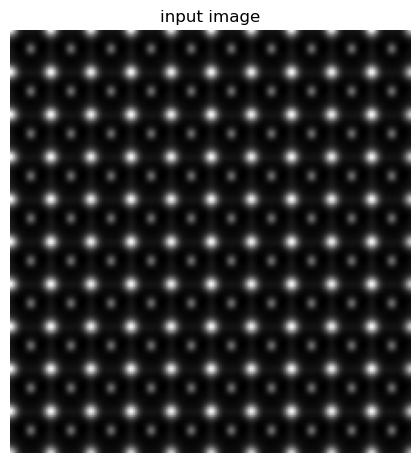

image (258, 244), sampling 0.016 nm/px, mode ADF, SEP 30


In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt



# ---------------------------------------------------------------------------
# Point IMAGE_PATH at your file to use real data; leave None for the synthetic
# self-test. Uncomment the ONE loading style that matches your file.
# ---------------------------------------------------------------------------
IMAGE_PATH = r'E:\vec-map\Sample images\PTO100-40nm-HAADF.dm4'           # e.g. r'C:\\data\\myimage.tif'  or  r'...\\scan.emd'
IMAGE_MODE = 'ADF'         # 'ADF' | 'iDPC' | 'ABF'  (ABF = atoms dark, inverted)
SEP = 30                   # A-A column spacing in px
POLARISATION_SIGN = +1     # arrow = B-cation displacement; set -1 for the opposite convention


# (A) TIFF / PNG / JPG : enter the pixel size yourself (nm/px):
s, img, sampling = load_stem_image(IMAGE_PATH, fallback_sampling=0.0159)
# (B) dm3 / dm4 / hdf5 : calibration read from the file:
# s, img, sampling = load_stem_image(IMAGE_PATH)
# (C) Velox .emd : choose a detector by name (or index):
# s, img, sampling = load_stem_image(IMAGE_PATH, signal='HAADF', frames='mean')

plt.figure(figsize=(5.5, 5.5)); plt.imshow(img, cmap='gray')
plt.title('input image'); plt.axis('off'); plt.show()

print(f'image {img.shape}, sampling {sampling:.5g} nm/px, mode {IMAGE_MODE}, SEP {SEP}')

## 2 · Detect the reference (A) columns

`detect_peaks` is a local-maximum finder. It first subtracts a smooth
background (`flatten=True`, default), so a single threshold works even with
strong illumination/thickness gradients or an iDPC low-frequency cloud — this
is what makes thresholding robust on real (and iDPC) images. Set `SEP` close to
the **A–A column spacing** in px (so the weaker B columns are not picked here)
and lower `threshold_rel` if columns are missed.

*(If you already have refined reference positions from another detector, set
`A_seed` to that `(N, 2)` array and skip straight to section 3.)*


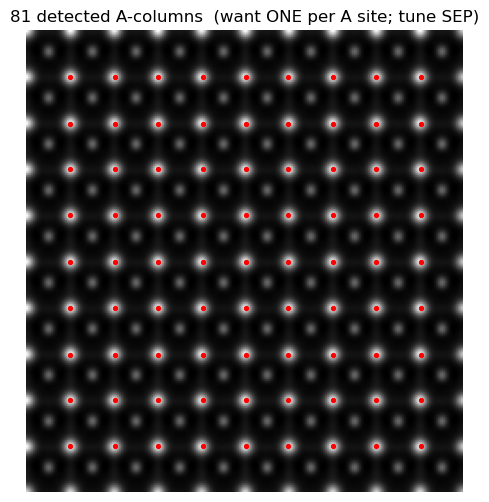

In [4]:
A_seed = detect_peaks(img, min_distance=SEP, image_mode=IMAGE_MODE,
                      threshold_rel=0.20, flatten=True)
margin = 5

h, w = img.shape

mask = (
    (A_seed[:,0] > margin) &
    (A_seed[:,0] < w - margin) &
    (A_seed[:,1] > margin) &
    (A_seed[:,1] < h - margin)
)

A_seed = A_seed[mask]

plt.figure(figsize=(6, 6))
plt.imshow(as_bright_atoms(img, IMAGE_MODE), cmap='gray')
plt.scatter(A_seed[:, 0], A_seed[:, 1], s=8, c='r')
plt.title(f'{len(A_seed)} detected A-columns  (want ONE per A site; tune SEP)')
plt.axis('off'); plt.show()

## 3 · Sub-pixel refinement & position precision

An independent 2-D Gaussian fit refines each column; `compare_refinements`
reports the Gaussian-vs-centre-of-mass disagreement in pm as a precision
proxy.

In [5]:
A = refine_gaussian(img, A_seed, box=max(4, SEP // 3), image_mode=IMAGE_MODE)
prec = compare_refinements(img, A_seed, sampling_nm=sampling,
                           box=max(4, SEP // 3), image_mode=IMAGE_MODE)
print(f'position precision proxy (Gaussian vs COM): '
      f'RMS {prec["rms_pm"]:.1f} pm, median {prec["median_pm"]:.1f} pm')

position precision proxy (Gaussian vs COM): RMS 2.2 pm, median 2.1 pm


## 4 · Lattice vectors & polarization vectors

On real (blurry) images the bright A columns bleed into the cage centre and
would capture a naive fit, so `measure_polarization` first **subtracts the A
columns** (`subtract_reference=True`, default) and locates the weak B column in
the residual. The diagnostic below shows that residual with the predicted cage
centres: **check that a B column sits near each red dot**. No intensity
separation between A and B is needed, so the same procedure works for iDPC/ABF
and, via `offset`, for non-perovskite structures.


### Complete-cage reference

The ideal central-column position is calculated only when all four measured A-column corners are present. Cells with a missing corner, an incomplete edge neighbourhood, or an unmatched lattice site are excluded before central-column refinement.


lattice vectors (px): [24.4  0. ] [ 0.  25.8]
vector lengths (px): 24.4 25.8
A columns used: 81
complete four-corner cages: 64
Only these complete cages will be used for displacement measurement.


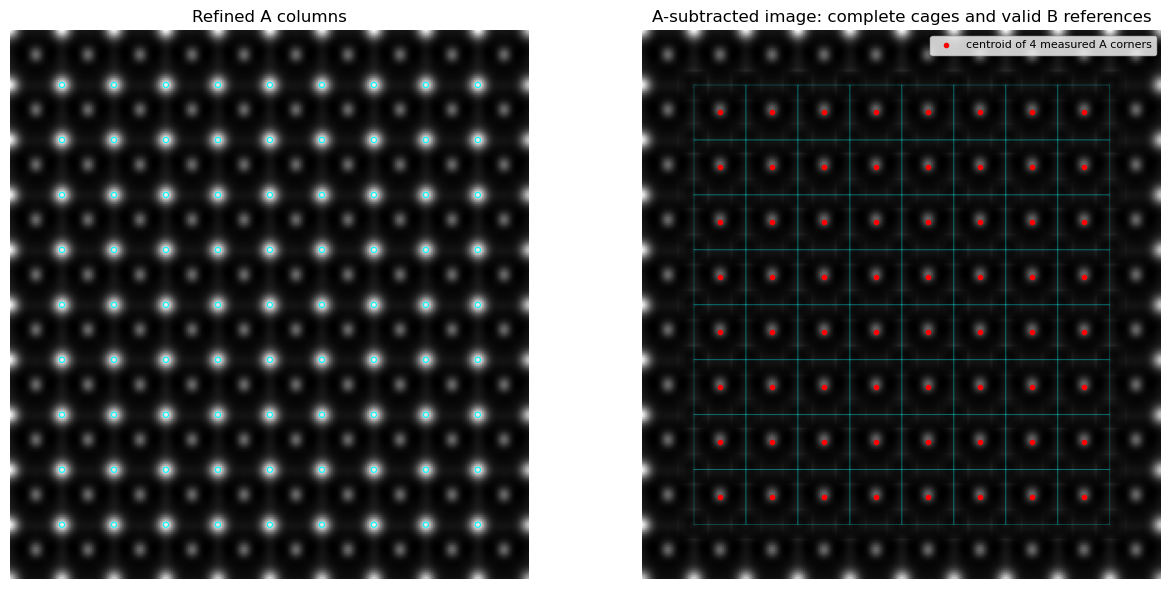

64 valid displacement vectors measured, median |disp| = 20.5 pm


In [6]:
v1, v2 = estimate_lattice_vectors(A)

print("lattice vectors (px):", np.round(v1, 2), np.round(v2, 2))
print(
    "vector lengths (px):",
    round(np.linalg.norm(v1), 2),
    round(np.linalg.norm(v2), 2),
)

# Maximum allowed mismatch between an expected cage corner and a measured A.
# Start with 0.28. For strongly strained data, try 0.30-0.35, but keep < 0.5.
CAGE_TOLERANCE = 0.28 * min(
    np.linalg.norm(v1),
    np.linalg.norm(v2),
)

residual = remove_columns_gaussian(
    img,
    A,
    image_mode=IMAGE_MODE,
)

ideal, cage_corner_indices = find_complete_perovskite_cages(
    A,
    v1,
    v2,
    tolerance=CAGE_TOLERANCE,
    return_corner_indices=True,
)

cell = 0.5 * (np.linalg.norm(v1) + np.linalg.norm(v2))
fit_box = max(3, int(round(0.30 * cell)))
fit_edge = fit_box + 1

h, w = img.shape

inside = (
    (ideal[:, 0] > fit_edge) &
    (ideal[:, 0] < w - fit_edge) &
    (ideal[:, 1] > fit_edge) &
    (ideal[:, 1] < h - fit_edge)
)

ideal_plot = ideal[inside]
cage_corner_indices_plot = cage_corner_indices[inside]

print(f"A columns used: {len(A)}")
print(f"complete four-corner cages: {len(ideal_plot)}")
print(
    "Only these complete cages will be used for displacement measurement."
)

fig, ax = plt.subplots(1, 2, figsize=(13, 6))

ax[0].imshow(as_bright_atoms(img, IMAGE_MODE), cmap="gray")
ax[0].scatter(
    A[:, 0],
    A[:, 1],
    s=14,
    facecolors="none",
    edgecolors="cyan",
    linewidths=0.8,
)
ax[0].set_title("Refined A columns")

ax[1].imshow(residual, cmap="gray")

# Draw every accepted four-corner cage.
polygon_order = [0, 1, 3, 2, 0]

for corner_ids in cage_corner_indices_plot:
    corners = A[corner_ids]
    ax[1].plot(
        corners[polygon_order, 0],
        corners[polygon_order, 1],
        color="cyan",
        linewidth=0.35,
        alpha=0.45,
    )

ax[1].scatter(
    ideal_plot[:, 0],
    ideal_plot[:, 1],
    s=9,
    c="red",
    label="centroid of 4 measured A corners",
)

ax[1].set_title(
    "A-subtracted image: complete cages and valid B references"
)
ax[1].legend(loc="upper right", fontsize=8)

for axis in ax:
    axis.set_xlim(0, w)
    axis.set_ylim(h, 0)
    axis.set_aspect("equal")
    axis.axis("off")

plt.tight_layout()
plt.show()

x, y, u, v = measure_polarization(
    img,
    A,
    v1,
    v2,
    image_mode=IMAGE_MODE,
    reference="complete_cage",
    cage_tolerance=CAGE_TOLERANCE,
    edge=fit_edge,
)

u = POLARISATION_SIGN * u
v = POLARISATION_SIGN * v

print(
    f"{len(x)} valid displacement vectors measured, "
    f"median |disp| = "
    f"{np.median(np.hypot(u, v)) * sampling * 1e3:.1f} pm"
)

### (Optional) start from externally refined positions

If you already have trusted sub-pixel positions for **both** sublattices — from
any column-finding tool you prefer — you can skip the detection and residual
steps entirely and use `polarmap` only for the displacement, statistics and
figures. With reference positions `A` and polar positions `B` (each an `(N, 2)`
array of `(x, y)` in pixels):

```python
v1, v2 = estimate_lattice_vectors(A)
x, y, u, v = polarization_from_sublattices(A, B, v1, v2, offset=(0.5, 0.5))
```

`polarization_from_sublattices` matches each A cage to its nearest measured B
and returns the displacement, which is exact when the input positions are good.


## 5 · Statistical descriptors

Magnitude (as a displacement, in pm) and orientation (deg). Outliers are removed
with a median/MAD rule before the statistics, and circular statistics are used
for the angle.


POLARIZATION-DISPLACEMENT DESCRIPTORS (n = 64)
  magnitude |d| (pm):  mean 20.5  median 20.5  std 0.0  MAD 0.0  min 20.5  max 20.6
  orientation (deg) :  circular-mean -90.0  circular-std 0.1  (R = 1.00)


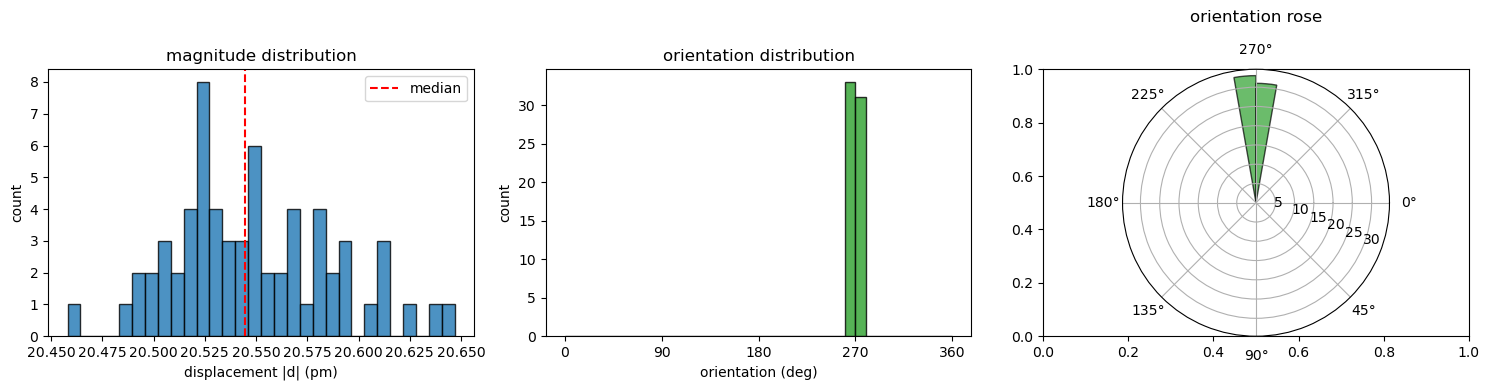

In [8]:
mag_pm = np.hypot(u, v) * sampling * 1e3          # displacement magnitude, pm
ang_deg = np.degrees(np.arctan2(v, u))            # -180..180

# robust outlier rejection on magnitude (median +/- 6 MAD)
med = np.median(mag_pm); mad = np.median(np.abs(mag_pm - med)) + 1e-9
keep = mag_pm < med + 6 * mad
mag_pm, ang_deg = mag_pm[keep], ang_deg[keep]

# circular statistics for the orientation
ar = np.radians(ang_deg)
mean_ang = np.degrees(np.arctan2(np.mean(np.sin(ar)), np.mean(np.cos(ar))))
R = np.hypot(np.mean(np.cos(ar)), np.mean(np.sin(ar)))    # resultant length (0..1)
circ_std = np.degrees(np.sqrt(-2 * np.log(max(R, 1e-9))))

print('POLARIZATION-DISPLACEMENT DESCRIPTORS (n = %d)' % mag_pm.size)
print('  magnitude |d| (pm):  mean %.1f  median %.1f  std %.1f  MAD %.1f  min %.1f  max %.1f'
      % (mag_pm.mean(), np.median(mag_pm), mag_pm.std(), mad, mag_pm.min(), mag_pm.max()))
print('  orientation (deg) :  circular-mean %.1f  circular-std %.1f  (R = %.2f)'
      % (mean_ang, circ_std, R))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(mag_pm, bins=30, color='tab:blue', edgecolor='k', alpha=0.8)
ax[0].axvline(np.median(mag_pm), color='r', ls='--', label='median')
ax[0].set_xlabel('displacement |d| (pm)'); ax[0].set_ylabel('count')
ax[0].set_title('magnitude distribution'); ax[0].legend()

ax[1].hist(np.mod(ang_deg, 360), bins=np.arange(0, 361, 10),
           color='tab:green', edgecolor='k', alpha=0.8)
ax[1].set_xlabel('orientation (deg)'); ax[1].set_ylabel('count')
ax[1].set_xticks([0, 90, 180, 270, 360]); ax[1].set_title('orientation distribution')

axp = plt.subplot(1, 3, 3, projection='polar')
counts, edges = np.histogram(np.mod(ar, 2*np.pi), bins=36, range=(0, 2*np.pi))
axp.bar((edges[:-1] + edges[1:]) / 2, counts, width=2*np.pi/36,
        color='tab:green', edgecolor='k', alpha=0.7)
axp.set_theta_zero_location('E'); axp.set_theta_direction(-1)
axp.set_title('orientation rose', pad=15)
plt.tight_layout(); plt.show()

## 6 · Polarization vector maps

Direction map (cyclic "rainbow" colour + round colour-wheel key), magnitude map
(uniform arrow length coloured by displacement), and a plain high-contrast
overlay — all with a contrasting stroke so arrows read over the atomic image.

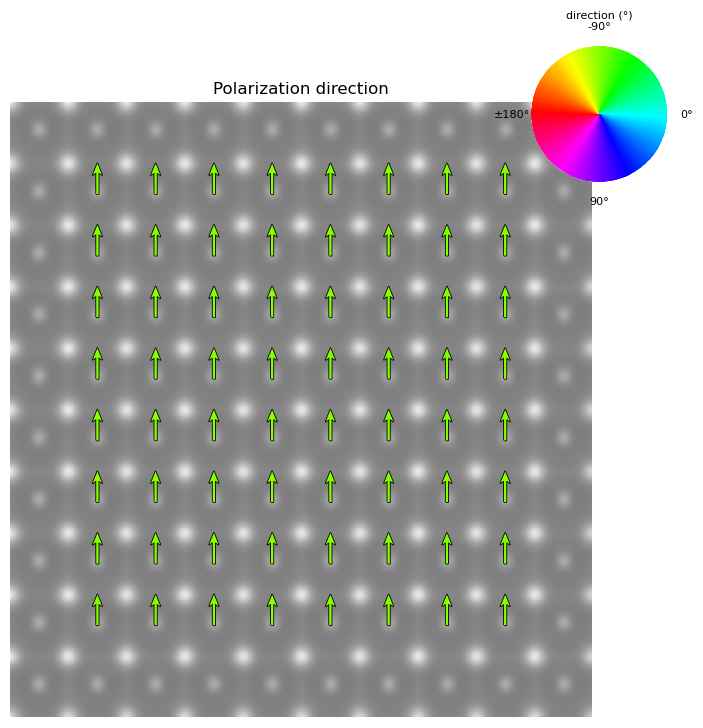

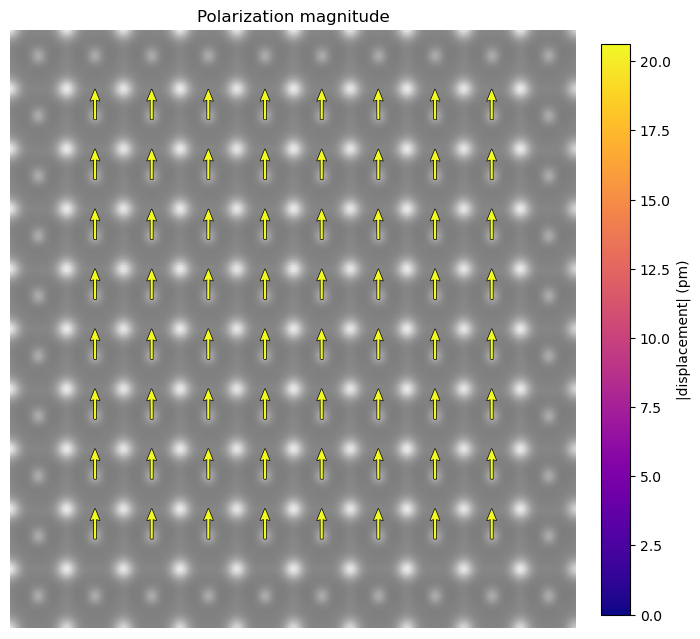

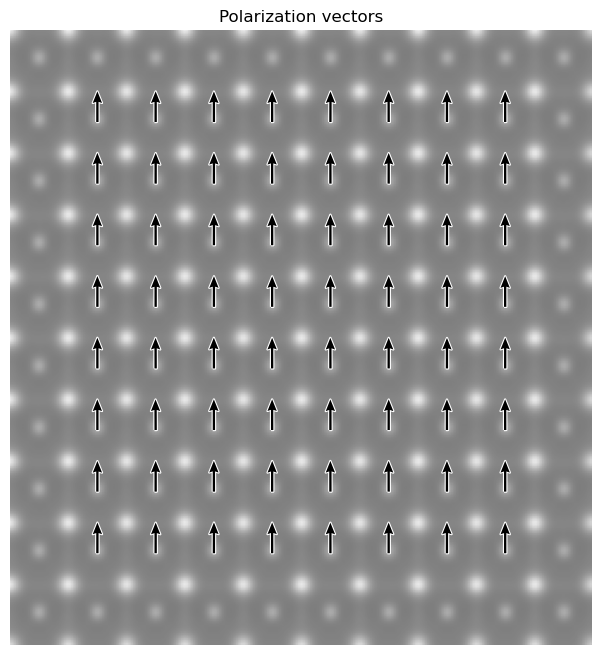

In [9]:
plot_polarisation_angle(x, y, u, v, image=img,
                        title='Polarization direction'); 
#plt.savefig(r'E:\Articol ultramicroscopy-20260729T081616Z-1-001\Articol ultramicroscopy\Revision MAM\polarization_direction.tiff', dpi=300, bbox_inches='tight')
plt.show()
plot_polarisation_magnitude(x, y, u, v, image=img, sampling=sampling,
                            unit='pm', title='Polarization magnitude'); 
#plt.savefig(r'E:\Articol ultramicroscopy-20260729T081616Z-1-001\Articol ultramicroscopy\Revision MAM\polarization_magnitude.tiff', dpi=300, bbox_inches='tight')
plt.show()
plot_polarisation_overlay(x, y, u, v, image=img,
                          title='Polarization vectors'); 
#plt.savefig(r'E:\Articol ultramicroscopy-20260729T081616Z-1-001\Articol ultramicroscopy\Revision MAM\polarization_vectors.tiff', dpi=300, bbox_inches='tight')
plt.show()

## 7 · Displacement → polarization (Born effective charge)

Displacement (pm) is **not** polarization. Convert with a Born effective charge
`Z*` and the unit-cell volume; edit these for your material (values below are
representative of PbTiO₃).

In [10]:
Z_STAR_B = 7.1                       # B-cation Born effective charge (units of e)
A_LAT, C_LAT = 0.402, 0.413          # tetragonal lattice params (nm) -- edit
CELL_VOL = A_LAT * A_LAT * C_LAT     # unit-cell volume (nm^3)

P = displacement_to_polarization(mag_pm, Z_STAR_B, CELL_VOL)
print('estimated polarization |P| (uC/cm^2):  mean %.1f  median %.1f  std %.1f'
      % (P.mean(), np.median(P), P.std()))
print('(semi-quantitative, single-sublattice estimate; report displacement in '
      'pm as the measured quantity.)')

estimated polarization |P| (uC/cm^2):  mean 35.0  median 35.0  std 0.1
(semi-quantitative, single-sublattice estimate; report displacement in pm as the measured quantity.)


## Comparison between the current workflow and the established VecMap

In [ ]:
import csv
import numpy as np
import pandas as pd 


def load_vecmap_displacements(csv_path):
    """
    Read a VecMap B-site displacement CSV.

    Only the first six entries of every row are needed:
        x, y, u, v, magnitude, angle

    The remaining entries describe the neighboring reference atoms.
    """
    rows = []

    with open(
        csv_path,
        mode="r",
        newline="",
        encoding="utf-8-sig",
    ) as file:
        reader = csv.reader(file, skipinitialspace=True)

        # Skip column names
        next(reader)

        for row in reader:
            values = [value.strip() for value in row]

            if len(values) < 6:
                continue

            rows.append([
                float(values[0]),  # measured B x
                float(values[1]),  # measured B y
                float(values[2]),  # x displacement
                float(values[3]),  # y displacement
                float(values[4]),  # magnitude in nm
                float(values[5]),  # VecMap angle
            ])

    dataframe = pd.DataFrame(
        rows,
        columns=[
            "x_B_px",
            "y_B_px",
            "u_px",
            "v_px",
            "magnitude_nm",
            "angle_vecmap_deg",
        ],
    )

    dataframe["magnitude_pm"] = (
        1000.0 * dataframe["magnitude_nm"]
    )

    # Cartesian convention used in the manuscript:
    # +x = right, +y = up, positive angles counter-clockwise.
    dataframe["angle_cart_deg"] = (
        np.degrees(
            np.arctan2(
                -dataframe["v_px"],
                dataframe["u_px"],
            )
        ) % 360.0
    )

    return dataframe

In [12]:
vecmap = load_vecmap_displacements(
    r"E:\vec-map\Sample images\PTO100-40nm-HAADF\PTO100-40nm-HAADF-B-site-disp.csv"
)

print(vecmap.head())
print(f"Number of VecMap vectors: {len(vecmap)}")
print(
    f"Median magnitude: "
    f"{vecmap['magnitude_pm'].median():.3f} pm"
)

       x_B_px      y_B_px      u_px      v_px  magnitude_nm  angle_vecmap_deg  \
0  207.402844  217.852257  0.001802 -1.292925      0.020687        270.079853   
1  207.403164  192.049669  0.002436 -1.296027      0.020736        270.107712   
2  183.000554  217.849009  0.000024 -1.297783      0.020765        270.001072   
3  207.398919  166.252419 -0.001763 -1.293683      0.020699        269.921928   
4  183.001252  192.052053 -0.000975 -1.294403      0.020710        269.956848   

   magnitude_pm  angle_cart_deg  
0     20.686823       89.920147  
1     20.736465       89.892288  
2     20.764531       89.998928  
3     20.698954       90.078072  
4     20.710458       90.043152  
Number of VecMap vectors: 64
Median magnitude: 20.715 pm


In [13]:
# Keep the physically defined atomic displacement:
# measured Ti position minus ideal cage center.
u_raw = np.asarray(u, dtype=float)
v_raw = np.asarray(v, dtype=float)

# Do not use POLARISATION_SIGN = -1 for the benchmark.
# The benchmark must compare the same atomic displacement definition.

In [14]:
sampling_pm = sampling * 1000.0  # nm/px -> pm/px

ours = pd.DataFrame({
    "x_ref_px": np.asarray(x, dtype=float),
    "y_ref_px": np.asarray(y, dtype=float),
    "u_px": u_raw,
    "v_px": v_raw,
})

# Measured Ti-column position
ours["x_B_px"] = ours["x_ref_px"] + ours["u_px"]
ours["y_B_px"] = ours["y_ref_px"] + ours["v_px"]

ours["dx_pm"] = sampling_pm * ours["u_px"]
ours["dy_image_pm"] = sampling_pm * ours["v_px"]

ours["magnitude_pm"] = np.hypot(
    ours["dx_pm"],
    ours["dy_image_pm"],
)

# Cartesian convention: image y is inverted.
ours["angle_cart_deg"] = (
    np.degrees(
        np.arctan2(
            -ours["v_px"],
            ours["u_px"],
        )
    ) % 360.0
)

print(ours.head())
print(f"Number of present-workflow vectors: {len(ours)}")

     x_ref_px   y_ref_px      u_px      v_px      x_B_px     y_B_px     dx_pm  \
0   36.599690  38.552974  0.000169 -1.286184   36.599859  37.266790  0.002697   
1   60.998745  38.553769 -0.000060 -1.284445   60.998685  37.269324 -0.000960   
2   85.398942  38.553498  0.000461 -1.281678   85.399403  37.271820  0.007370   
3  109.799411  38.552361 -0.000233 -1.284058  109.799178  37.268303 -0.003724   
4  134.199152  38.552584  0.003612 -1.282468  134.202765  37.270116  0.057800   

   dy_image_pm  magnitude_pm  angle_cart_deg  
0   -20.578940     20.578940       89.992490  
1   -20.551126     20.551126       90.002677  
2   -20.506844     20.506845       89.979410  
3   -20.544924     20.544924       90.010386  
4   -20.519484     20.519566       89.838609  
Number of present-workflow vectors: 64


In [15]:
from scipy.spatial import cKDTree


def mutual_nearest_matches(
    xy_first,
    xy_second,
    tolerance_px=1.5,
):
    """
    Match corresponding atomic columns using mutual nearest neighbors.

    A match is accepted only if:
      1. the second point is the nearest neighbor of the first;
      2. the first point is also the nearest neighbor of the second;
      3. their separation is below tolerance_px.
    """
    xy_first = np.asarray(xy_first, dtype=float)
    xy_second = np.asarray(xy_second, dtype=float)

    tree_second = cKDTree(xy_second)
    distances, second_indices = tree_second.query(
        xy_first,
        k=1,
    )

    tree_first = cKDTree(xy_first)
    _, first_indices_back = tree_first.query(
        xy_second,
        k=1,
    )

    first_indices = np.arange(len(xy_first))

    accepted = (
        np.isfinite(distances)
        & (distances <= tolerance_px)
        & (
            first_indices_back[second_indices]
            == first_indices
        )
    )

    return (
        first_indices[accepted],
        second_indices[accepted],
        distances[accepted],
    )

In [16]:
idx_ours, idx_vecmap, match_distances = (
    mutual_nearest_matches(
        ours[["x_B_px", "y_B_px"]].to_numpy(),
        vecmap[["x_B_px", "y_B_px"]].to_numpy(),
        tolerance_px=1.5,
    )
)

ours_m = (
    ours.iloc[idx_ours]
    .reset_index(drop=True)
)

vecmap_m = (
    vecmap.iloc[idx_vecmap]
    .reset_index(drop=True)
)

print(
    f"Matched sites: {len(ours_m)} "
    f"out of {len(ours)} and {len(vecmap)}"
)

print(
    f"Median matching distance: "
    f"{np.median(match_distances):.4f} px"
)

Matched sites: 64 out of 64 and 64
Median matching distance: 0.0175 px


In [17]:
comparison = pd.DataFrame({
    "x_px": ours_m["x_B_px"],
    "y_px": ours_m["y_B_px"],

    "u_ours_px": ours_m["u_px"],
    "v_ours_px": ours_m["v_px"],

    "u_vecmap_px": vecmap_m["u_px"],
    "v_vecmap_px": vecmap_m["v_px"],

    "mag_ours_pm": ours_m["magnitude_pm"],
    "mag_vecmap_pm": vecmap_m["magnitude_pm"],

    "angle_ours_deg": ours_m["angle_cart_deg"],
    "angle_vecmap_deg": vecmap_m["angle_cart_deg"],

    "matching_distance_px": match_distances,
})

In [18]:
comparison["delta_u_pm"] = sampling_pm * (
    comparison["u_ours_px"]
    - comparison["u_vecmap_px"]
)

comparison["delta_v_pm"] = sampling_pm * (
    comparison["v_ours_px"]
    - comparison["v_vecmap_px"]
)

comparison["delta_magnitude_pm"] = (
    comparison["mag_ours_pm"]
    - comparison["mag_vecmap_pm"]
)

In [19]:
def angular_difference_deg(angle_first, angle_second):
    """
    Smallest signed angular difference in [-180, 180).
    """
    difference_rad = np.deg2rad(
        np.asarray(angle_first)
        - np.asarray(angle_second)
    )

    return np.degrees(
        np.arctan2(
            np.sin(difference_rad),
            np.cos(difference_rad),
        )
    )


comparison["delta_angle_deg"] = (
    angular_difference_deg(
        comparison["angle_ours_deg"],
        comparison["angle_vecmap_deg"],
    )
)

In [20]:
magnitude_bias_pm = np.mean(
    comparison["delta_magnitude_pm"]
)

magnitude_mae_pm = np.mean(
    np.abs(comparison["delta_magnitude_pm"])
)

magnitude_rmse_pm = np.sqrt(
    np.mean(
        comparison["delta_magnitude_pm"]**2
    )
)

vector_rmse_pm = np.sqrt(
    np.mean(
        comparison["delta_u_pm"]**2
        + comparison["delta_v_pm"]**2
    )
)

median_abs_angle_deg = np.median(
    np.abs(comparison["delta_angle_deg"])
)

mean_abs_angle_deg = np.mean(
    np.abs(comparison["delta_angle_deg"])
)

print("\nVecMap benchmark")
print("----------------")
print(f"Matched sites: {len(comparison)}")

print(
    f"Present workflow median magnitude: "
    f"{comparison['mag_ours_pm'].median():.3f} pm"
)

print(
    f"VecMap median magnitude: "
    f"{comparison['mag_vecmap_pm'].median():.3f} pm"
)

print(
    f"Magnitude bias, workflow - VecMap: "
    f"{magnitude_bias_pm:.3f} pm"
)

print(
    f"Magnitude MAE: "
    f"{magnitude_mae_pm:.3f} pm"
)

print(
    f"Magnitude RMSE: "
    f"{magnitude_rmse_pm:.3f} pm"
)

print(
    f"Vector RMSE: "
    f"{vector_rmse_pm:.3f} pm"
)

print(
    f"Median absolute angular difference: "
    f"{median_abs_angle_deg:.3f}°"
)

print(
    f"Mean absolute angular difference: "
    f"{mean_abs_angle_deg:.3f}°"
)


VecMap benchmark
----------------
Matched sites: 64
Present workflow median magnitude: 20.545 pm
VecMap median magnitude: 20.715 pm
Magnitude bias, workflow - VecMap: -0.173 pm
Magnitude MAE: 0.173 pm
Magnitude RMSE: 0.174 pm
Vector RMSE: 0.176 pm
Median absolute angular difference: 0.037°
Mean absolute angular difference: 0.048°


In [21]:
comparison.to_csv(
    r"E:\vec-map\PTO100_point_by_point_VecMap_comparison.csv",
    index=False,
)

PermissionError: [Errno 13] Permission denied: 'E:\\vec-map\\PTO100_point_by_point_VecMap_comparison.csv'

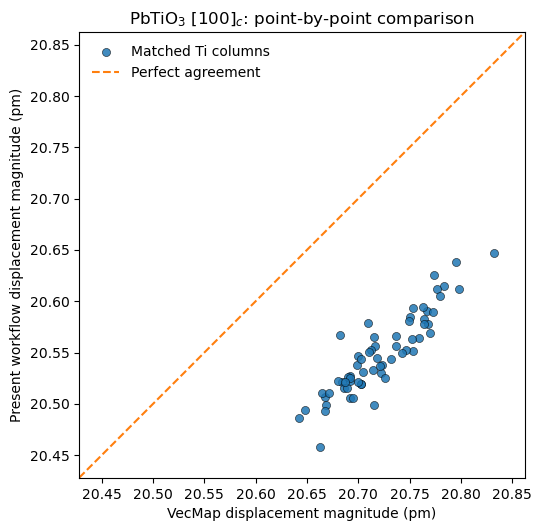

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.read_csv(
    "PTO100_point_by_point_VecMap_comparison.csv"
)

fig, ax = plt.subplots(figsize=(5.5, 5.5))

ax.scatter(
    comparison["mag_vecmap_pm"],
    comparison["mag_ours_pm"],
    s=34,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.4,
    alpha=0.85,
    label="Matched Ti columns",
)

minimum = min(
    comparison["mag_vecmap_pm"].min(),
    comparison["mag_ours_pm"].min(),
)

maximum = max(
    comparison["mag_vecmap_pm"].max(),
    comparison["mag_ours_pm"].max(),
)

padding = 0.03

ax.plot(
    [minimum - padding, maximum + padding],
    [minimum - padding, maximum + padding],
    color="tab:orange",
    linestyle="--",
    linewidth=1.5,
    label="Perfect agreement",
)

ax.set_xlim(minimum - padding, maximum + padding)
ax.set_ylim(minimum - padding, maximum + padding)

ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("VecMap displacement magnitude (pm)")
ax.set_ylabel("Present workflow displacement magnitude (pm)")

ax.set_title(
    r"PbTiO$_3$ $[100]_c$: point-by-point comparison"
)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

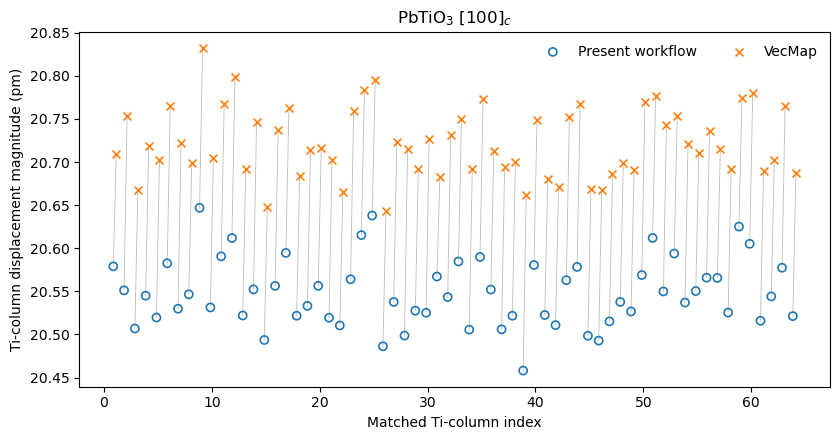

In [25]:
site = np.arange(1, len(comparison) + 1)

fig, ax = plt.subplots(figsize=(8.5, 4.5))

offset = 0.14

ax.scatter(
    site - offset,
    comparison["mag_ours_pm"],
    s=34,
    marker="o",
    facecolors="none",
    edgecolors="tab:blue",
    linewidths=1.2,
    label="Present workflow",
    zorder=3,
)

ax.scatter(
    site + offset,
    comparison["mag_vecmap_pm"],
    s=32,
    marker="x",
    color="tab:orange",
    linewidths=1.2,
    label="VecMap",
    zorder=4,
)

for index, ours_value, vecmap_value in zip(
    site,
    comparison["mag_ours_pm"],
    comparison["mag_vecmap_pm"],
):
    ax.plot(
        [index - offset, index + offset],
        [ours_value, vecmap_value],
        color="0.75",
        linewidth=0.6,
        zorder=1,
    )

ax.set_xlabel("Matched Ti-column index")
ax.set_ylabel("Ti-column displacement magnitude (pm)")
ax.set_title(r"PbTiO$_3$ $[100]_c$")
ax.legend(frameon=False, ncol=2)

plt.tight_layout()
plt.savefig(
    r"E:\vec-map\Sample images\PTO100-40nm-HAADF\PTO100_point_by_point_magnitude_comparison.tiff",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 9 · A general reference model — the [110] projection and beyond

Sections 2–8 are two special cases of a single idea. A polarization
measurement is always *displacement of a polar column from a reference position
that would be occupied in the non-polar (centrosymmetric) structure*. Only the
**recipe for that reference position** changes between structures, and every
recipe is built from a small number of neighbouring **reference columns** whose
ideal fractional coordinates in the projected cell are known:

| Structure / projection | Reference columns | Ideal position of the polar column |
|---|---|---|
| Perovskite `[100]` | 4 A-cations forming a square cage | centroid of the 4 corners (fraction `½, ½`) |
| Perovskite `[110]` | 2 A-cations along the projected `c` | point a fraction `f` along the pair (`f = ½` for the symmetric midpoint) |
| Wurtzite `[0001]` (GaN/AlN) | 1 cation | cation position + fixed offset `u_ref·c` (`u_ref = 3/8`) |
| Any polar structure | the columns that bracket the polar site | the same fractional-coordinate interpolation of those columns |

The cell below implements the **two-column pair** case, which is what a
perovskite `[110]` projection needs. Along `[110]` the projected cell no longer
shows a four-fold A-cage around the B-column; instead the B/Ti-containing column
lies **between two bright A/Pb columns** along the projected polar axis. The
reference is therefore the point a fraction `REFERENCE_FRACTION` of the way from
one A column to the next:

$$\mathbf{r}_\text{ideal} = (1-f)\,\mathbf{r}_0 + f\,\mathbf{r}_1,
\qquad \mathbf{\Delta r} = \mathbf{r}_\text{polar} - \mathbf{r}_\text{ideal}.$$

Setting `REFERENCE_FRACTION = 0.5` places the reference at the midpoint of the
pair, which is the centrosymmetric position for the projected `[110]`
perovskite. The displacement `Δr` and its angle are then read out exactly as in
the cage case.

### Turning this into any structure with a few small changes

Because the reference is built from *measured* columns and a *fractional
coordinate*, adapting the same cell to a different structure needs only three
inputs, all exposed as parameters:

1. **`REFERENCE_FRACTION` (`f`)** — the fractional position of the polar column
   between the two reference columns. Use `f = ½` for a symmetric midpoint
   (perovskite `[110]`). Use the crystallographic internal parameter for an
   asymmetric pair — for example `f = 3/8` reproduces the wurtzite cation→N
   spacing along `c`. When `f ≠ ½` the two ends of the pair are not
   interchangeable, so the search direction matters (next point).

2. **`PAIR_AXIS_HINT`** — an approximate direction, in image coordinates
   (`x` right, `y` down), pointing from the first reference column towards the
   second along the projected polar axis. `(0, +1)` means "the next reference is
   below"; `(0, −1)` means "above". For `f = ½` either sign gives the same
   midpoint; for `f ≠ ½` the sign fixes which end is `r₀` and which is `r₁`, and
   therefore the sign of the internal offset. `estimate_pair_vector` uses this
   hint only to pick, for every reference column, the nearest neighbour in that
   half-plane, then robustly medians those vectors into a single pair vector —
   so a rough hint (±25° by default) is enough.

3. **The two sublattices themselves** — which columns are "reference" (bright)
   and which is the "polar/target" (weaker) column. Here they are separated by
   fitted Gaussian amplitude (`split_columns_by_fitted_amplitude`), which is
   robust when the two sublattices differ in intensity but not by a wide margin.
   If your polar column is *not* distinguishable by intensity, supply the two
   sets of positions directly and skip the split.

Everything downstream is structure-independent. The reference is always
interpolated between **complete** pairs only (`find_complete_reference_pairs`
requires a measured column at *both* ends before it accepts a site), so edge
columns and missing neighbours cannot manufacture a false reference — the same
completeness guarantee the four-corner cage gives in section 4. The polar column
is then located in the **reference-subtracted residual**, fitted with a 2-D
Gaussian, and quality-filtered on amplitude, ellipticity and maximum
displacement. The output `(x, y, u, v)` feeds the identical statistics
(section 5), vector maps (section 6) and Born-charge conversion (section 7).

In short: **if you know where the polar atom should sit in the projected unit
cell — expressed as a fractional position between columns you can see — you can
map its displacement.** Perovskite `[100]`, perovskite `[110]` and wurtzite
`[0001]` differ only in that fractional recipe and in how many reference columns
bracket the site; the machinery around them is shared. For a structure with a
more complex projected basis (e.g. a polar column bracketed by more than two
references, or offset in two directions at once), the same pattern extends by
using a fractional interpolation over the relevant `k` reference columns in
place of the two-column pair.


pixel calibration from file: 0.016 nm/px = 0.016 nm/px
image: (258, 276); sampling = 16 pm/px
all peaks = 357, bright references = 135, global weak candidates = 150
estimated pair vector (px) = [ 0.    25.804] ; length = 25.804 px
complete valid pairs / measured weak columns = 120; median dx = 1.31 pm; median dy = -12.60 pm; median |dr| = 12.67 pm
experimental image


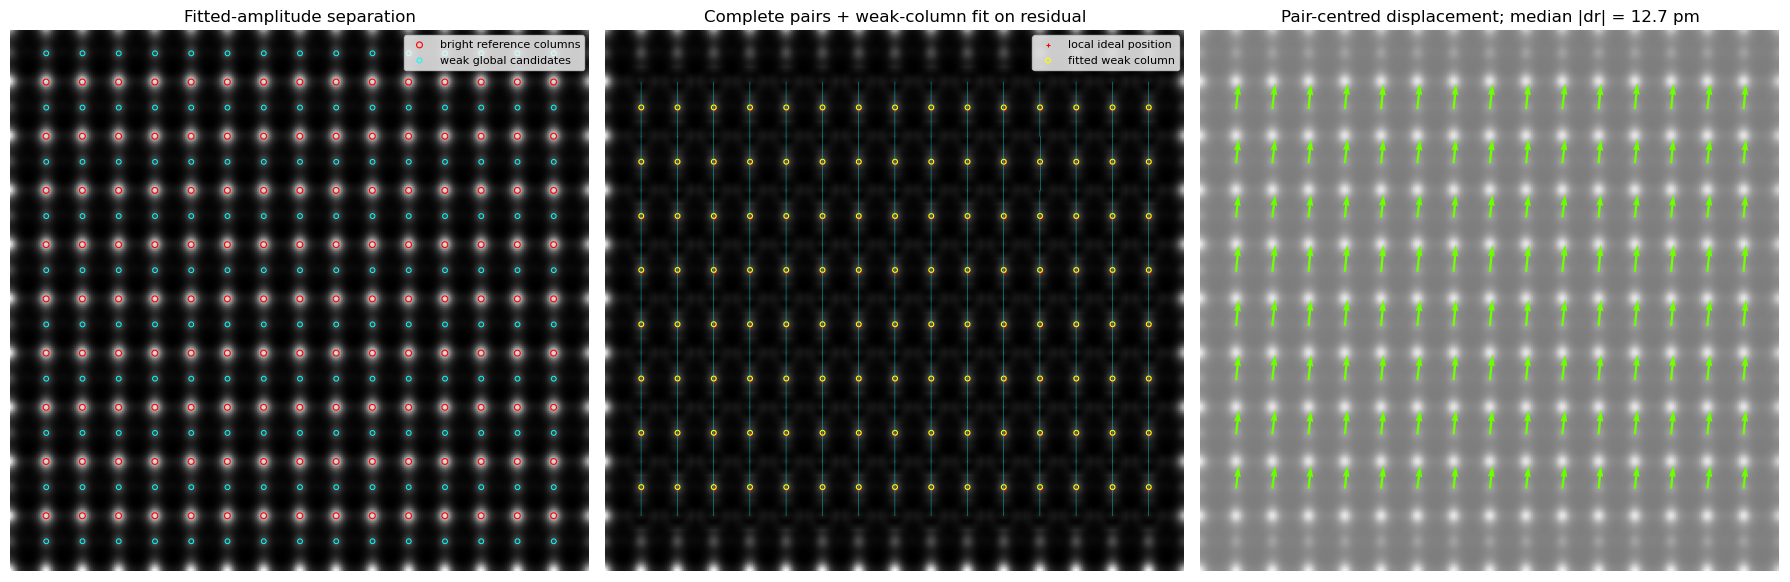

In [ ]:
# ================== Pair-centred displacement for a [110] projection ==================
# For a perovskite viewed along [110], set REFERENCE_FRACTION = 0.5:
# the weaker B-site/Ti-containing column is referenced to the midpoint of TWO
# neighbouring bright A-site/Pb columns along the projected c direction.
#
# For a structure whose target sits at a known fraction f along the pair, set
# REFERENCE_FRACTION = f. When f != 0.5 the pair is not symmetric, so
# PAIR_AXIS_HINT must point from the first reference towards the second along
# +c (f and 1 - f are then distinct endpoints).

from scipy.spatial import cKDTree



def split_columns_by_fitted_amplitude(image, seeds, box=3,
                                      image_mode="ADF", edge=0):
    """Refine every detected peak and split bright/weak columns by 1-D 2-means.

    Returns the REFINED sub-pixel coordinates (from the Gaussian fit), not the
    integer local-maximum seeds, so the pair geometry is built on accurate
    positions.
    """
    refined, pars = refine_gaussian(
        image,
        seeds,
        box=box,
        image_mode=image_mode,
        return_params=True,
    )

    amp = np.asarray(pars["amplitude"], dtype=float)
    sx = np.asarray(pars["sigma_x"], dtype=float)
    sy = np.asarray(pars["sigma_y"], dtype=float)
    h, w = np.asarray(image).shape

    valid = (
        np.isfinite(refined).all(axis=1)
        & np.isfinite(amp)
        & np.isfinite(sx)
        & np.isfinite(sy)
        & (amp > 0)
        & (refined[:, 0] > edge)
        & (refined[:, 0] < w - edge)
        & (refined[:, 1] > edge)
        & (refined[:, 1] < h - edge)
    )

    refined = refined[valid]
    amp = amp[valid]

    if len(refined) < 4:
        raise RuntimeError(
            "Too few valid peaks for intensity separation. Lower "
            "ALL_PEAK_THRESHOLD or check IMAGE_MODE."
        )

    # Robust 1-D two-cluster split of fitted amplitudes.
    threshold = float(np.median(amp))
    for _ in range(100):
        low = amp[amp < threshold]
        high = amp[amp >= threshold]
        if len(low) == 0 or len(high) == 0:
            break
        new_threshold = 0.5 * (low.mean() + high.mean())
        if abs(new_threshold - threshold) < 1e-8:
            threshold = new_threshold
            break
        threshold = new_threshold

    bright = amp >= threshold
    return (
        refined[bright],
        refined[~bright],
        amp[bright],
        amp[~bright],
        threshold,
    )


def estimate_pair_vector(reference_xy, axis_hint=(0.0, 1.0),
                         k_neighbors=12, angle_tolerance_deg=25.0):
    """Estimate the nearest positive reference-reference translation.

    axis_hint is expressed in image coordinates (x right, y down). For a
    vertical projected c-axis use (0, +1). For an upward +c direction use
    (0, -1). The latter distinction matters when reference_fraction != 0.5.
    """
    reference_xy = np.asarray(reference_xy, dtype=float)
    axis = np.asarray(axis_hint, dtype=float)
    axis_norm = np.linalg.norm(axis)
    if axis_norm == 0:
        raise ValueError("PAIR_AXIS_HINT cannot be the zero vector")
    axis /= axis_norm

    tree = cKDTree(reference_xy)
    k = min(k_neighbors + 1, len(reference_xy))
    _, indices = tree.query(reference_xy, k=k)
    indices = np.atleast_2d(indices)

    selected = []
    cos_min = np.cos(np.deg2rad(angle_tolerance_deg))

    for i, point in enumerate(reference_xy):
        neighbours = reference_xy[np.atleast_1d(indices[i])[1:]]
        vectors = neighbours - point
        lengths = np.linalg.norm(vectors, axis=1)
        projection = vectors @ axis
        cosine = np.divide(
            projection,
            lengths,
            out=np.full_like(projection, -np.inf),
            where=lengths > 0,
        )
        good = (projection > 0) & (cosine >= cos_min)
        if np.any(good):
            candidates = vectors[good]
            candidate_lengths = lengths[good]
            selected.append(candidates[np.argmin(candidate_lengths)])

    selected = np.asarray(selected, dtype=float)
    if len(selected) < 3:
        raise RuntimeError(
            "Could not estimate the pair vector. Adjust PAIR_AXIS_HINT or "
            "increase PAIR_ANGLE_TOL_DEG."
        )

    median_vector = np.median(selected, axis=0)
    deviation = np.linalg.norm(selected - median_vector, axis=1)
    median_deviation = np.median(deviation)
    mad = np.median(np.abs(deviation - median_deviation))
    limit = max(2.5 * mad, 0.20 * np.linalg.norm(median_vector), 1.0)
    keep = deviation <= limit

    return np.median(selected[keep], axis=0)


def find_complete_reference_pairs(reference_xy, pair_vector,
                                  reference_fraction=0.5,
                                  tolerance=None,
                                  return_pair_indices=False):
    """Build local ideal weak-column positions from COMPLETE two-column pairs.

    A pair is accepted only when a measured reference column exists near both
    ends of the expected pair vector. The ideal target position is interpolated
    from the TWO MEASURED endpoints:

        r_ideal = (1-f) r_0 + f r_1.

    Therefore, an edge column or a missing neighbour cannot create a false
    central reference position.
    """
    reference_xy = np.asarray(reference_xy, dtype=float)
    pair_vector = np.asarray(pair_vector, dtype=float)
    pair_spacing = np.linalg.norm(pair_vector)

    if pair_spacing <= 0:
        raise ValueError("pair_vector must be non-zero")
    if not (0.0 < reference_fraction < 1.0):
        raise ValueError("reference_fraction must lie between 0 and 1")

    if tolerance is None:
        tolerance = 0.28 * pair_spacing
    if not (0.0 < tolerance < 0.5 * pair_spacing):
        raise ValueError(
            "PAIR_TOLERANCE must be positive and smaller than half the "
            "reference-reference spacing"
        )

    tree = cKDTree(reference_xy)
    accepted = {}

    for i, r0 in enumerate(reference_xy):
        distance, j = tree.query(r0 + pair_vector, k=1)
        j = int(j)

        if j == i or distance > tolerance:
            continue

        actual_vector = reference_xy[j] - r0
        if np.dot(actual_vector, pair_vector) <= 0:
            continue

        # Because only the +pair_vector direction is searched, each physical
        # pair should appear once. The key still protects against duplicates.
        key = (i, j)
        ideal = ((1.0 - reference_fraction) * r0
                 + reference_fraction * reference_xy[j])
        accepted[key] = (ideal, np.array([i, j], dtype=int))

    if accepted:
        ideal_xy = np.vstack([item[0] for item in accepted.values()])
        pair_indices = np.vstack([item[1] for item in accepted.values()])
    else:
        ideal_xy = np.empty((0, 2), dtype=float)
        pair_indices = np.empty((0, 2), dtype=int)

    if return_pair_indices:
        return ideal_xy, pair_indices
    return ideal_xy


def local_residual_maxima(residual, ideal_xy, search_radius):
    """Detect one weak-column seed near every valid local reference."""
    residual = np.asarray(residual, dtype=float)
    h, w = residual.shape
    seeds = np.empty_like(np.asarray(ideal_xy, dtype=float))

    for i, (x, y) in enumerate(ideal_xy):
        xi, yi = int(round(x)), int(round(y))
        x0 = max(0, xi - search_radius)
        x1 = min(w, xi + search_radius + 1)
        y0 = max(0, yi - search_radius)
        y1 = min(h, yi + search_radius + 1)

        patch = residual[y0:y1, x0:x1]
        py, px = np.unravel_index(np.argmax(patch), patch.shape)
        seeds[i] = (x0 + px, y0 + py)

    return seeds


def measure_pair_centered_displacement(image, reference_xy, pair_vector,
                                       reference_fraction=0.5,
                                       image_mode="ADF",
                                       pair_tolerance=None,
                                       subtract_reference=True,
                                       reference_subtract_box=None,
                                       weak_search_radius=None,
                                       weak_fit_box=None,
                                       max_displacement=None):
    """Measure weak-column displacement relative to complete local pairs."""
    bright_image = as_bright_atoms(image, image_mode)
    reference_xy = np.asarray(reference_xy, dtype=float)
    pair_spacing = np.linalg.norm(pair_vector)

    ideal_xy, pair_indices = find_complete_reference_pairs(
        reference_xy,
        pair_vector,
        reference_fraction=reference_fraction,
        tolerance=pair_tolerance,
        return_pair_indices=True,
    )

    if len(ideal_xy) == 0:
        raise RuntimeError(
            "No complete reference pairs were found. Check the bright-column "
            "selection, PAIR_AXIS_HINT and PAIR_TOLERANCE_FRACTION."
        )

    if weak_fit_box is None:
        weak_fit_box = max(3, int(round(0.16 * pair_spacing)))
    if weak_search_radius is None:
        weak_search_radius = max(2, int(round(0.20 * pair_spacing)))
    if max_displacement is None:
        max_displacement = 0.30 * pair_spacing
    if reference_subtract_box is None:
        reference_subtract_box = max(4, int(round(0.22 * pair_spacing)))

    # Keep the local-search and Gaussian-fit windows fully inside the image.
    edge_for_fit = weak_fit_box + weak_search_radius + 1
    h, w = bright_image.shape
    inside = (
        (ideal_xy[:, 0] > edge_for_fit)
        & (ideal_xy[:, 0] < w - edge_for_fit)
        & (ideal_xy[:, 1] > edge_for_fit)
        & (ideal_xy[:, 1] < h - edge_for_fit)
    )
    ideal_xy = ideal_xy[inside]
    pair_indices = pair_indices[inside]

    if len(ideal_xy) == 0:
        raise RuntimeError("All complete pairs were removed by the fit-edge test")

    # Remove the bright reference columns first. The weak atoms are detected in
    # this residual, not by a global threshold on the original HAADF image.
    residual = (
        remove_columns_gaussian(
            bright_image,
            reference_xy,
            box=reference_subtract_box,
            image_mode="ADF",
        )
        if subtract_reference
        else bright_image.copy()
    )

    weak_seeds = local_residual_maxima(
        residual,
        ideal_xy,
        search_radius=weak_search_radius,
    )

    weak_found, fit_pars = refine_gaussian(
        residual,
        weak_seeds,
        box=weak_fit_box,
        image_mode="ADF",
        return_params=True,
    )

    displacement = weak_found - ideal_xy
    amplitude = np.asarray(fit_pars["amplitude"], dtype=float)
    ellipticity = np.asarray(fit_pars["ellipticity"], dtype=float)

    good = (
        np.isfinite(weak_found).all(axis=1)
        & np.isfinite(amplitude)
        & (amplitude > 0)
        & np.isfinite(ellipticity)
        & (ellipticity < 3.0)
        & (np.linalg.norm(displacement, axis=1) < max_displacement)
    )

    # Reject obvious noise fits while keeping real spatial intensity variation.
    if np.any(good):
        median_amplitude = np.nanmedian(amplitude[good])
        if np.isfinite(median_amplitude) and median_amplitude > 0:
            good &= amplitude > 0.25 * median_amplitude

    return {
        "x": ideal_xy[good, 0],
        "y": ideal_xy[good, 1],
        "u": displacement[good, 0],
        "v": displacement[good, 1],
        "ideal_xy": ideal_xy[good],
        "found_xy": weak_found[good],
        "weak_seeds": weak_seeds[good],
        "pair_indices": pair_indices[good],
        "residual": residual,
        "amplitude": amplitude[good],
        "ellipticity": ellipticity[good],
    }


# ---------------------------- User settings ----------------------------

IMAGE_PATH_110 = r'E:\vec-map\Sample images\PTO110-40nm-HAADF.dm4'

IMAGE_MODE_110 = "ADF"


# 0.5: pair midpoint, appropriate for the projected two-reference [110]
# test used here. 0.375: the synthetic wurtzite internal-coordinate test.
REFERENCE_FRACTION = 0.5

# Approximate +pair direction in IMAGE coordinates: x right, y down.
PAIR_AXIS_HINT = (0.0, 1.0)
PAIR_VECTOR_PX = None       # e.g. np.array([0.0, 30.0]) to override estimation
PAIR_ANGLE_TOL_DEG = 25.0
PAIR_TOLERANCE_FRACTION = 0.28

# Detect all atomic columns first; fitted amplitude then separates bright/weak.
# This distance must be smaller than the bright-weak separation, not the full
# bright-bright repeat. For the synthetic example, 8 px is appropriate.
ALL_PEAK_SEP = 8
ALL_PEAK_THRESHOLD = 0.20
COLUMN_FIT_BOX = 3
EDGE_PX = 10

POLARISATION_SIGN = +1      # +1: measured target displacement found - ideal
ARROW_VIS = 15


# ---------------------------- Load or synthesize ----------------------------


_, img_110, sampling_110 = load_stem_image(IMAGE_PATH_110)
pair_vector_true = None
expected_text = "experimental image"

sampling_pm_110 = sampling_110 * 1e3


# ------------------ Detect and separate bright/weak columns ------------------
all_seed_110 = detect_peaks(
    img_110,
    min_distance=ALL_PEAK_SEP,
    image_mode=IMAGE_MODE_110,
    threshold_rel=ALL_PEAK_THRESHOLD,
    flatten=True,
)

reference_110, weak_global_110, amp_ref_110, amp_weak_110, amp_threshold_110 = (
    split_columns_by_fitted_amplitude(
        img_110,
        all_seed_110,
        box=COLUMN_FIT_BOX,
        image_mode=IMAGE_MODE_110,
        edge=EDGE_PX,
    )
)


# -------------------- Estimate the complete-pair geometry --------------------
if PAIR_VECTOR_PX is None:
    pair_vector_110 = estimate_pair_vector(
        reference_110,
        axis_hint=PAIR_AXIS_HINT,
        angle_tolerance_deg=PAIR_ANGLE_TOL_DEG,
    )
else:
    pair_vector_110 = np.asarray(PAIR_VECTOR_PX, dtype=float)

pair_spacing_110 = np.linalg.norm(pair_vector_110)
pair_tolerance_110 = PAIR_TOLERANCE_FRACTION * pair_spacing_110

result_110 = measure_pair_centered_displacement(
    img_110,
    reference_110,
    pair_vector_110,
    reference_fraction=REFERENCE_FRACTION,
    image_mode=IMAGE_MODE_110,
    pair_tolerance=pair_tolerance_110,
)

xw = result_110["x"]
yw = result_110["y"]
uw = POLARISATION_SIGN * result_110["u"]
vw = POLARISATION_SIGN * result_110["v"]
mag_pm_110 = np.hypot(uw, vw) * sampling_pm_110

print(f"image: {img_110.shape}; sampling = {sampling_pm_110:.4g} pm/px")
print(
    f"all peaks = {len(all_seed_110)}, bright references = {len(reference_110)}, "
    f"global weak candidates = {len(weak_global_110)}"
)
print(
    "estimated pair vector (px) =",
    np.round(pair_vector_110, 3),
    f"; length = {pair_spacing_110:.3f} px",
)
print(
    f"complete valid pairs / measured weak columns = {len(xw)}; "
    f"median dx = {np.median(uw) * sampling_pm_110:.2f} pm; "
    f"median dy = {np.median(vw) * sampling_pm_110:.2f} pm; "
    f"median |dr| = {np.median(mag_pm_110):.2f} pm"
)
print(expected_text)


# -------------------------------- Diagnostics --------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(as_bright_atoms(img_110, IMAGE_MODE_110), cmap="gray")
ax[0].scatter(
    reference_110[:, 0],
    reference_110[:, 1],
    s=18,
    facecolors="none",
    edgecolors="red",
    linewidths=0.8,
    label="bright reference columns",
)
ax[0].scatter(
    weak_global_110[:, 0],
    weak_global_110[:, 1],
    s=12,
    facecolors="none",
    edgecolors="cyan",
    linewidths=0.7,
    label="weak global candidates",
)
ax[0].set_title("Fitted-amplitude separation")
ax[0].legend(loc="upper right", fontsize=8)

ax[1].imshow(result_110["residual"], cmap="gray")
for pair_ids in result_110["pair_indices"]:
    endpoints = reference_110[pair_ids]
    ax[1].plot(
        endpoints[:, 0],
        endpoints[:, 1],
        color="cyan",
        linewidth=0.45,
        alpha=0.55,
    )
ax[1].scatter(
    result_110["ideal_xy"][:, 0],
    result_110["ideal_xy"][:, 1],
    s=12,
    c="red",
    marker="+",
    linewidths=0.8,
    label="local ideal position",
)
ax[1].scatter(
    result_110["found_xy"][:, 0],
    result_110["found_xy"][:, 1],
    s=12,
    facecolors="none",
    edgecolors="yellow",
    linewidths=0.8,
    label="fitted weak column",
)
ax[1].set_title("Complete pairs + weak-column fit on residual")
ax[1].legend(loc="upper right", fontsize=8)

show_dimmed_image(ax[2], as_bright_atoms(img_110, IMAGE_MODE_110))
angle_110 = np.degrees(np.arctan2(vw, uw))
q = ax[2].quiver(
    xw,
    yw,
    uw * ARROW_VIS,
    vw * ARROW_VIS,
    angle_110,
    angles="xy",
    scale_units="xy",
    scale=1,
    cmap=CYCLIC_CMAP,
    clim=(-180, 180),
    width=0.004,
)
ax[2].set_title(
    f"Pair-centred displacement; median |dr| = "
    f"{np.median(mag_pm_110):.1f} pm"
)

for axis in ax:
    axis.set_xlim(0, img_110.shape[1])
    axis.set_ylim(img_110.shape[0], 0)
    axis.set_aspect("equal")
    axis.axis("off")

plt.tight_layout()
#plt.savefig(r'E:\Articol ultramicroscopy-20260729T081616Z-1-001\Articol ultramicroscopy\Revision MAM\pair_centered_displacementPZT110.tiff', dpi=300, bbox_inches='tight')
plt.show()

---
**To use your data:** set `IMAGE_PATH`, `IMAGE_MODE` and `SEP` in section 1,
re-run, and tune `SEP` / `threshold_rel` in section 2 until the columns are
cleanly detected. Everything after that is automatic.

**Reference model — pick the one that matches your projection:**

- *Perovskite* `[100]`: cage centroid of the 4 A-corners
  (`measure_polarization(..., reference="complete_cage")`, sections 4–6).
- *Perovskite* `[110]`: midpoint of the two A-columns along the projected
  polar axis — the pair model with `REFERENCE_FRACTION = 0.5` (section 9).
- *Wurtzite / dumbbell* (GaN, AlN): fixed cation→polar offset
  (`displacement_from_offset`, section 8), equivalently the pair model with the
  crystallographic internal parameter as `REFERENCE_FRACTION`.
- *Any other polar structure*: interpolate the ideal position from the columns
  that bracket the polar site, using its known fractional coordinate (section 9).

The displacement/arrow points **from the reference toward the measured polar
column** (i.e. along the cation displacement); if your convention needs the
opposite sign, negate `(u, v)`.

Strain (GPA) is in the companion notebook `Strain_GPA_workflow.ipynb`.
